_Date: 27th June 2026 &nbsp;&nbsp; Authors: Soledad, Benay, and Andre_

# Automated Customer Reviews (NLP)

> **Note:** Sections 0, 1, and 2 are in a separate notebook (`Project_NLP_Sections_0_1_2.ipynb`).
> This notebook loads their outputs from disk and continues from Section 3 onward.

## Setup — Load outputs from Sections 0–2

Load the cleaned, merged, and labeled dataset produced by the previous notebook.
Also reload `df_primary` for Section 3 clustering (which needs the original product-level columns).

In [ ]:
import pandas as pd
import numpy as np

# ── Load df_merged — output of Section 2 ─────────────────────────────────────
# Contains: asin, rating, title, text, sentiment, label, review_len_words
df_merged = pd.read_csv('df_merged_clean.csv')
print(f"df_merged loaded: {df_merged.shape}")
print(df_merged['sentiment'].value_counts())

df_merged loaded: (175000, 10)
sentiment
Positive    70000
Negative    70000
Neutral     35000
Name: count, dtype: int64


/tmp/ipykernel_5483/3873354741.py:6: DtypeWarning: Columns (4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv('df_merged_clean.csv')


In [ ]:
# Reload the original Datafiniti dataset (1429_1.csv).
# This is the raw Kaggle dataset used as the source for product metadata.
# We reload it here because the merged sentiment dataset does not retain
# the original product names and category information needed for clustering.

import os

df_primary = pd.read_csv('1429_1.csv')

# Rename for consistency with Section 3 code
df_primary_renamed = df_primary.rename(columns={
    'asins':                'asin',
    'reviews.rating':       'rating',
    'reviews.title':        'title',
    'reviews.text':         'text',
    'reviews.didPurchase':  'verified_purchase',
    'reviews.numHelpful':   'helpful_vote',
    'reviews.username':     'user_id',
    'reviews.date':         'timestamp',
})

print(f"df_primary_renamed ready: {df_primary_renamed.shape}")

df_primary_renamed ready: (34660, 21)


/tmp/ipykernel_5483/1920080714.py:8: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_primary = pd.read_csv('1429_1.csv')


---

<h2 style="background-color:#D8BFD8; color:black; padding:8px; border-radius:4px;">
Section 3: Product Category Clustering
</h2>

<span style="color: purple"> **3.1 Feature representation**     </span>  
<span style="color: purple">**3.2 Creation of a sub-dataset to perform the categorization**    </span>  
- 3.2.1 Creating a subdataset from the Primary Dataset with selected columns: **Name**, **Category** and **Review**  </span>  
- 3.2.2 Filter the **Name** column
- 3.2.3 Filter the "**Category** column
- 3.2.4 Filter the **Review** column

<span style="color: purple">**3.3 Clustering model**:  </span>  group products into 4-6 meta-categories using KMEANS clustering (k=4, 5, 6) + evaluation    
<span style="color: purple">**3.4 Statistical sampling / validation**   </span>  — sample within clusters to manually verify coherence; the "did the clustering actually make sense" check.    
<span style="color: purple">**3.4 Visualization**  </span>  — 2D projection (PCA or UMAP) of clusters with hover tooltips for interactive exploration; this is the visual deliverable for this section.    
<span style="color: purple">**3.5 Cluster labeling**  </span>   — assign human-readable names to each cluster for use in the summarization step.    


<h3 style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;">
3.1 Feature Representation
</h3>
Decision on how reviews/products are embedded for clustering (e.g. sentence embeddings vs existing category text).  

In [ ]:
df_merged.columns

Index(['asin', 'rating', 'title', 'text', 'verified_purchase', 'helpful_vote',
       'user_id', 'timestamp', 'review_len_words', 'sentiment'],
      dtype='object')

In [ ]:
df_primary_renamed.columns

Index(['id', 'name', 'asin', 'brand', 'categories', 'keys', 'manufacturer',
       'timestamp', 'reviews.dateAdded', 'reviews.dateSeen',
       'verified_purchase', 'reviews.doRecommend', 'reviews.id',
       'helpful_vote', 'rating', 'reviews.sourceURLs', 'text', 'title',
       'reviews.userCity', 'reviews.userProvince', 'user_id'],
      dtype='object')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
#Prod is a clean  table, one row per unique product, with just the product-describing columns
prod = (
    df_primary_renamed
    .drop_duplicates(subset="asin")[["id", "name", "brand", "manufacturer", "categories"]]
    .reset_index(drop=True)
)
prod.head()

,id,name,brand,manufacturer,categories
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta..."
1,AVqVGZO3nnc1JgDc3jGK,Kindle Oasis E-reader with Leather Charging Co...,Amazon,Amazon,"eBook Readers,Kindle E-readers,Computers & Tab..."
2,AVpe9CMS1cnluZ0-aoC5,"Amazon Kindle Lighted Leather Cover,,,\r\nAmaz...",Amazon,Amazon,"Electronics,eBook Readers & Accessories,Covers..."
3,AVpfBEWcilAPnD_xTGb7,"Kindle Keyboard,,,\r\nKindle Keyboard,,,",Amazon,Amazon,"Kindle Store,Amazon Devices,Electronics"
4,AVqkIiKWnnc1JgDc3khH,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,Amazon,"Tablets,Fire Tablets,Electronics,Computers,Com..."


In [ ]:
print(f"Reviews: {len(df_primary):,}  ->  Unique products: {len(prod)}")

Reviews: 34,660  ->  Unique products: 42


#### Observations:

The id column (which is the unique product identifier — effectively the ASIN, since asins and id are the same value in this dataset) only takes 42 distinct values across all those rows.

Each row is one customer's review of one product, and popular products get reviewed thousands of times, while a few have only 1.

In [ ]:
#_______________1. We count the Frequency across all products___________________________

#A. Split the comma-separated 'categories' string into a clean list of tags
# per product, e.g. "Electronics,Tablets,Fire Tablets" -> ["Electronics", "Tablets", "Fire Tablets"]

prod["category_list"] = prod["categories"].fillna("").apply(
    lambda s: [t.strip() for t in s.split(",") if t.strip()])


print(prod["category_list"])
print("**"*30)
prod["n_tags"] = prod["category_list"].apply(len)
print(prod["n_tags"])

#B. Flatten all tags across all products into one big list, then count occurrences
all_tags = [tag for tags in prod["category_list"] for tag in tags]
tag_counts = Counter(all_tags)

0     [Electronics, iPad & Tablets, All Tablets, Fir...
1     [eBook Readers, Kindle E-readers, Computers & ...
2     [Electronics, eBook Readers & Accessories, Cov...
3           [Kindle Store, Amazon Devices, Electronics]
4     [Tablets, Fire Tablets, Electronics, Computers...
5     [Tablets, Fire Tablets, Computers & Tablets, A...
6     [Amazon Devices & Accessories, Amazon Device A...
7     [Electronics, iPad & Tablets, All Tablets, Com...
8     [Computers/Tablets & Networking, Tablets & eBo...
9     [Fire Tablets, Tablets, Computers & Tablets, A...
10    [Kindle E-readers, Electronics Features, Compu...
11    [Computers & Tablets, E-Readers & Accessories,...
12    [Fire Tablets, Tablets, Computers & Tablets, A...
13    [Frys, Software & Books, eReaders & Accessorie...
14    [Electronics, Categories, Streaming Media Play...
15    [Computers/Tablets & Networking, Tablets & eBo...
16    [Amazon Device Accessories, Kindle Store, Kind...
17    [Tablets, Fire Tablets, Computers & Tablet

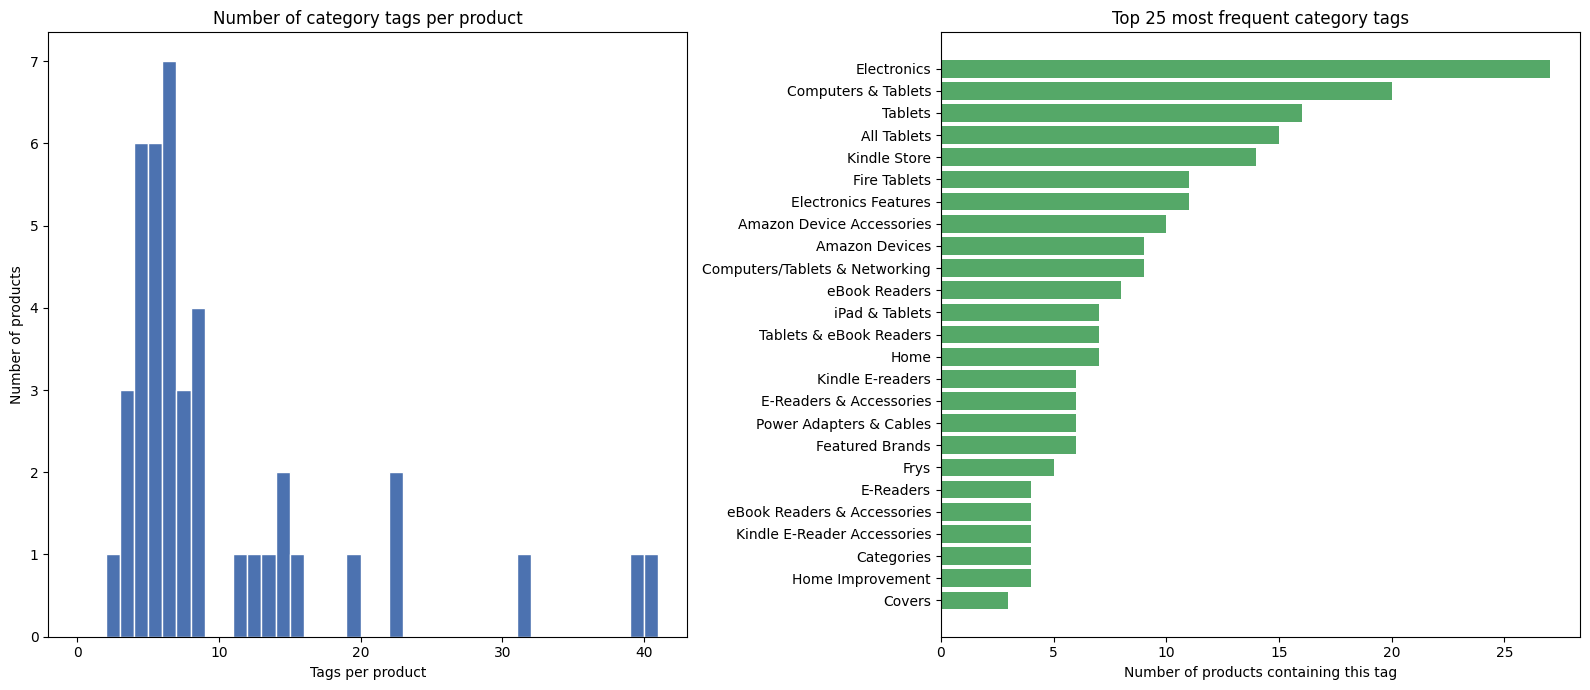

In [ ]:
top_n = 25
top_tags = tag_counts.most_common(top_n)
labels, counts = zip(*top_tags)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

#Left Plot: distribution of how many tags each product has (messiness indicator)
axes[0].hist(prod["n_tags"], bins=range(0, prod["n_tags"].max() + 2), color="#4C72B0", edgecolor="white")
axes[0].set_title("Number of category tags per product")
axes[0].set_xlabel("Tags per product")
axes[0].set_ylabel("Number of products")

#Right Plot: most frequent individual tags (horizontal bar, easiest to read)
axes[1].barh(labels[::-1], counts[::-1], color="#55A868")
axes[1].set_title(f"Top {top_n} most frequent category tags")
axes[1].set_xlabel("Number of products containing this tag")

plt.tight_layout()
plt.show()

#### Key Observations:
A wide spread here (e.g., some products with 3 tags, others with 40) tells us the categories field is inconsistently populated -- important context before we try to use it as a clustering feature.

Tags like **Electronics** appearing in most products are NOT useful for telling products apart -- this plot is what motivates filtering them out later in this notebook

<h3 style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;">
3.2 Creation of a sub-dataset to perform the categorization
</h3>

### 3.2.1 Build the DataSet to perform the Products Catgorization

In [ ]:
# ── 1. Build the subdataset ───────────────────────────────────────────────────
# We only need three columns for clustering: the raw category tags that came
# with the dataset, the product name, and the review text.

df_prim_cluster = df_primary[["id","categories", "name", "reviews.text"]]
print(f"Starting shape: {df_prim_cluster.shape}")

Starting shape: (34660, 4)


In [ ]:
# Drop the null review rows
df_prim_cluster = df_prim_cluster.dropna(subset=["reviews.text"]).reset_index(drop=True)
print(f"After dropping null reviews: {df_prim_cluster.shape}")

After dropping null reviews: (34659, 4)


### 3.2.2 Filter the "Products" column

In [ ]:
# ── 2. Clean the "product" name ─────────────────────────────────────────────────
import re
import pandas as pd

def clean_product_name(name):
    if pd.isna(name):
        return ""

    #Step 1: strip the duplication artifact — many names look like
    # "Echo (White),,,\r\nEcho (White),,," — keep only the first segment
    name = re.split(r",,,|\\r\\n|\r\n", str(name))[0]

    # Step 2: lowercase for consistent matching
    name = name.lower()

    # Step 3: remove anything inside parentheses — usually colour/variant info
    name = re.sub(r"\(.*?\)", "", name)

    # Step 4: remove pure numbers and storage/size specs like "8gb", "256gb",
    name = re.sub(r"\b\d+(\.\d+)?\s*(gb|tb|mb|in|inches|\"|\"|ppi|mp|mah|hz)\b", "", name)

    # Step 5: remove standalone numbers (e.g. the "16" in "Kindle Fire 16")
    name = re.sub(r"\b\d+\b", "", name)

    # Step 6: remove noise phrases that describe listing conditions/features rather than the product type
    noise_phrases = [
        "includes special offers", "special offers", "wi-fi", "wifi",
        "display", "hd", "ultra hd", "4k", "new", "brand new",
        "with alexa", "black", "white", "blue", "red", "green",
        "magenta", "tangerine", "silver", "gold", "space gray",
        "monochrome", "touchscreen", "ips", "tablet wifi",
        "high-resolution", "high resolution", "adaptive built-in light",
        "pagepress sensors", "lighted leather", "kid-proof",
        "official oem", "power adapter", "usb", "oem", "gb",
        "th generation", "nd generation", "rd generation", "st generation",
    ]
    for phrase in noise_phrases:
        name = name.replace(phrase, " ")

    # Step 7: strip leftover punctuation (hyphens, commas, dots used as
    # separators once the surrounding words are removed) and collapse
    # multiple spaces into one
    name = re.sub(r"[,\-\.\/\\]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()

    return name

df_prim_cluster["name_clean"] = df_prim_cluster["name"].apply(clean_product_name)


In [ ]:
# Sanity check — print a few before/after pairs so you can see what changed
print("\nName cleaning examples:")
sample_idx = df_prim_cluster["name"].dropna().drop_duplicates().head(6).index
for i in sample_idx:
    print(f"  BEFORE: {df_prim_cluster.loc[i, 'name'][:80]}")
    print(f"  AFTER:  {df_prim_cluster.loc[i, 'name_clean']}")
    print()


Name cleaning examples:
  BEFORE: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, 
  AFTER:  all fire tablet

  BEFORE: Kindle Oasis E-reader with Leather Charging Cover - Merlot, 6 High-Resolution Di
  AFTER:  kindle oasis e reader with leather charging cover merlot

  BEFORE: Amazon Kindle Lighted Leather Cover,,,
Amazon Kindle Lighted Leather Cover,,,
  AFTER:  amazon kindle cover

  BEFORE: Amazon Kindle Lighted Leather Cover,,,
Kindle Keyboard,,,
  AFTER:  amazon kindle cover

  BEFORE: Kindle Keyboard,,,
Kindle Keyboard,,,
  AFTER:  kindle keyboard

  BEFORE: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, 
  AFTER:  all fire tablet



### 3.2.3 Filter the "Categories" column

In [ ]:
# ── 3. Filter the "categories" column ──────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# ── Step A: treat each product's category string as one "document" ────────────
# We deduplicate to product level first (one row per unique id), so a tag that
# appears on a product with 10,000 reviews doesn't get counted 10,000 times and artificially look more "common" than it really is.
prod_cats = (df_prim_cluster.drop_duplicates(subset="id")[["id", "categories"]].copy())
prod_cats["categories"] = prod_cats["categories"].fillna("")


# ── Step B: vectorise tokens at the TAG level, not the word level ───────────────────
def comma_tokenizer(text):
    return [t.strip().lower() for t in text.split(",") if t.strip()]

vectorizer = TfidfVectorizer(
    tokenizer=comma_tokenizer,
    analyzer="word",       # required when using a custom tokenizer
    token_pattern=None,    # disable the default regex, we handle splitting above
    min_df=3,              # tag must appear in at least 3 products to be considered
    max_df=0.40,           # tag must appear in FEWER than 40% of products
                           # ↑ this is the key line — anything more common than
                           #   60% of products is too generic to discriminate
                           #   ("Electronics" appears in 27/42 = 64%, so it's cut)
)
vectorizer.fit(prod_cats["categories"])

# ── Step C: read back the tags that survived the filter ──────────────────────
# get_feature_names_out() returns every tag whose document frequency fell
# inside the [min_df, max_df] window — i.e. the tags that are specific enough to be useful but common enough to be reliable.
surviving_tags = vectorizer.get_feature_names_out()
print(f"Tags surviving the filter: {len(surviving_tags)}")
print()
print(surviving_tags)

# Build a set for fast membership lookup
surviving_tag_set = set(surviving_tags)

def filter_categories_auto(cat_string):
    if pd.isna(cat_string):
        return ""
    tags = [t.strip().lower() for t in cat_string.split(",") if t.strip()]
    # Keep only tags the TF-IDF filter deemed discriminative
    kept_tags = [t for t in tags if t in surviving_tag_set]
    all_words = " ".join(kept_tags).split()
    unique_words = list(dict.fromkeys(all_words))  # preserves order, removes duplicates
    return " ".join(unique_words)

df_prim_cluster["categories_clean"] = df_prim_cluster["categories"].apply(filter_categories_auto)

Tags surviving the filter: 45

['alarms & sensors' 'all tablets' 'amazon device accessories'
 'amazon devices' 'amazon echo' 'categories' 'computers'
 'computers/tablets & networking' 'covers' 'e-readers'
 'e-readers & accessories' 'ebook readers' 'ebook readers & accessories'
 'electronics features' 'featured brands' 'fire tablet accessories'
 'fire tablets' 'frys' 'garage & office' 'holiday shop' 'home'
 'home automation' 'home improvement' 'home safety & security'
 'home security' 'ipad & tablets' 'kindle e-reader accessories'
 'kindle e-readers' 'kindle fire (2nd generation) accessories'
 'kindle store' 'movies' 'music' 'power adapters & cables' 'smart home'
 'smart home & connected living' 'smart home & home automation devices'
 'smart hubs' 'smart hubs & wireless routers' 'streaming media players'
 'tablet accessories' 'tablets' 'tablets & ebook readers' 'tech toys'
 'tvs entertainment' 'voice assistants']


In [ ]:
df_prim_cluster.head(2)

,id,categories,name,reviews.text,name_clean,categories_clean
0,AVqkIhwDv8e3D1O-lebb,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",This product so far has not disappointed. My c...,all fire tablet,ipad & tablets all fire
1,AVqkIhwDv8e3D1O-lebb,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",great for beginner or experienced person. Boug...,all fire tablet,ipad & tablets all fire


### 3.2.4 Filter the "Reviews" column
To filter the "reviews" column, there are two apporaches:  

**Approach A:**   (_Deprioritized_)  
    For each review row we call the Claude API and ask it to return only the words from that review that signal what *kind of product* is being
    reviewed: stripping out sentiment, filler, personal anecdote, etc.
    Due to the high number of rows this can't be done in one sitting. So we:
    1. Write results to a **JSONL checkpoint file** as we go (one line per row)  
    2. On startup, **read back any rows already processed and skip them**.  
    3. Run in batches of **BATCH_SIZE rows**, sleeping between calls to stay within rate limits. Re-run this cell any time to continue from where it
    stopped — it will never re-process a row it already has.

**Approach B:**
Our first attempt at extracting product-relevant signal from the reviews.text column used an LLM (via API): for each review, we prompted the model to return only the words that hint at what type of product was being reviewed, stripping out sentiment and filler. This produced high-quality output, but with ~35,000 reviews and one API call per row, the full run took several hours and was repeatedly interrupted by rate limits and connectivity issues, making it impractical to re-run while iterating on the rest of the pipeline. We needed an approach that runs locally, with no API calls, no rate limits, and fast enough to re-run on demand.

- **Comparing RAKE and YAKE**. We considered two classic, fully local keyword-extraction algorithms: RAKE and YAKE — and tested both directly against samples of our actual review data before choosing one, rather than picking either by assumption.

    - **RAKE (Rapid Automatic Keyword Extraction)** splits text into candidate phrases at stopwords and punctuation, then scores words by frequency and co-occurrence with neighboring words, ranking phrases by the sum of their word scores.
    
    - **YAKE (Yet Another Keyword Extractor)** scores candidate phrases using a different combination of statistical signals: word frequency, position in the text (earlier = more likely to be a main topic), casing (capitalized terms like "Kindle" or "Echo" are weighted as more meaningful), and how diverse the surrounding context is.


##### > Approach A for fitlering the "Reviews" column (Depriotized)

```python
#!pip install openai

# ── Prompt ───────────────────────────────────────────────────────────────────
SYSTEM_PROMPT = """You are a product categorisation assistant.
Your only job is to read Amazon product reviews and extract the words
that reveal what TYPE or CATEGORY of product is being reviewed.

Return ONLY a short space-separated list of keywords — no sentences,
no explanations, no punctuation. If a review gives no useful signal,
return the single word: unknown

Good keywords: device names, product type words, feature words specific
to a product category (e.g. "screen", "battery", "speaker", "page",
"reading", "streaming", "charging", "voice", "tablet", "ereader").

Bad keywords: sentiment words ("great", "terrible", "love"), generic
words ("product", "item", "thing", "purchase", "bought"), names,
delivery comments, price comments."""

def make_prompt(review_text):
    # We include one worked example so the model knows exactly what format
    # to return, then the real review to process.
    return f"""Example:
            Review: "The screen is bright and easy to read. Great for reading books
            on the bus. Battery lasts all week."
            Keywords: screen reading books battery ereader
            
            Now extract keywords from this review:
            Review: \"\"\"{review_text}\"\"\"
            Keywords:"""


from openai import OpenAI
print("Testing OpenAI connection...")

# ── Overview ──────────────────────────────────────────────────────────────────
from google.colab import userdata
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

CHECKPOINT_FILE = "review_keywords_checkpoint.jsonl"
BATCH_SIZE      = 50       # rows to process per "chunk" before saving progress
SLEEP_BETWEENÇ   = 0.5      # seconds between API calls (adjust if rate-limited)
MAX_ROWS        = None     # set to e.g. 500 to do a trial run; None = all rows
client = OpenAI(api_key=OPENAI_API_KEY)

try:
    test = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=5,
        messages=[{"role": "user", "content": "say hi"}],
    )
    print(f"Connection OK — response: {test.choices[0].message.content}")
    
except Exception as e:
    print(f"Connection FAILED: {e}")
    print("Fix the error above before running the loop.")
    raise   # stops execution here so you don't start a broken loop

# ── Load existing checkpoint ──────────────────────────────────────────────────
# The checkpoint file stores one JSON object per line, each containing the
# row index and the extracted keywords string. On restart, we read these
# back and skip any index already present.

already_done = {}
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                record = json.loads(line)
                already_done[record["idx"]] = record["keywords"]
    print(f"Loaded {len(already_done)} rows from checkpoint — will skip these.")
else:
    print("No checkpoint found — starting fresh.")


# ── Decide which rows to process ─────────────────────────────────────────────
all_indices = df_prim_cluster.index.tolist()
if MAX_ROWS is not None:
    all_indices = all_indices[:MAX_ROWS]

to_process = [i for i in all_indices if i not in already_done]
print(f"Rows remaining to process: {len(to_process)} / {len(all_indices)}")



# ── API call helper ───────────────────────────────────────────────────────────
import os
import re
import json
import time
import requests
import pandas as pd


def extract_keywords(review_text):
    if not isinstance(review_text, str) or len(review_text.strip()) < 15:
        return "unknown"
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            max_tokens=60,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": make_prompt(review_text)},
            ],
        )
        keywords = response.choices[0].message.content.strip()
        keywords = re.sub(r"[^\w\s]", " ", keywords)
        keywords = re.sub(r"\s+", " ", keywords).strip().lower()
        return keywords if keywords else "unknown"

    except Exception as e:
        print(f"  Error: {e}")
        return "error"

# ── Main processing loop ──────────────────────────────────────────────────────
print(f"\nStarting extraction — {len(to_process)} rows to go...")
start_time = time.time()

with open(CHECKPOINT_FILE, "a") as checkpoint_f:
    for batch_start in range(0, len(to_process), BATCH_SIZE):
        batch = to_process[batch_start : batch_start + BATCH_SIZE]

        for idx in batch:
            review_text = df_prim_cluster.loc[idx, "reviews.text"]
            keywords    = extract_keywords(review_text)

            # Write to checkpoint immediately — if we crash mid-batch,
            # everything up to this point is already saved.
            record = {"idx": idx, "keywords": keywords}
            checkpoint_f.write(json.dumps(record) + "\n")
            checkpoint_f.flush()

            already_done[idx] = keywords
            print(f"  Row {idx}: {keywords[:60]}", flush=True)
            time.sleep(SLEEP_BETWEEN)

        # Progress report after each batch
        done_so_far = batch_start + len(batch)
        elapsed     = time.time() - start_time
        rate        = done_so_far / elapsed if elapsed > 0 else 0
        remaining   = (len(to_process) - done_so_far) / rate if rate > 0 else 0
        print(
            f"  Batch done: {done_so_far}/{len(to_process)} rows  |  "
            f"{rate:.1f} rows/sec  |  ~{remaining/60:.0f} min remaining"
        )

print("\nExtraction complete (or paused). Re-run this cell to continue.")


# ── Attach results back to the dataframe ─────────────────────────────────────
# Build the 'review_keywords' column from the checkpoint dict.
# Rows not yet processed get an empty string so downstream code doesn't break.
df_prim_cluster["review_keywords"] = df_prim_cluster.index.map(
    lambda i: already_done.get(i, "")
)

n_done    = (df_prim_cluster["review_keywords"] != "").sum()
n_total   = len(df_prim_cluster)
n_unknown = (df_prim_cluster["review_keywords"] == "unknown").sum()

print(f"\nRows with keywords:  {n_done} / {n_total}")
print(f"Rows marked unknown: {n_unknown}  (very short / no signal reviews)")
print(f"Rows not yet done:   {n_total - n_done}")
print()


print("Sample output:")
print(
    df_prim_cluster[df_prim_cluster["review_keywords"] != ""]
    [["reviews.text", "review_keywords"]]
    .head(5)
    .to_string()
)

```


##### > Approach B: Review of Yake and Rake methods and selection of Yake

In [ ]:
!pip install yake
!pip install rake-nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 33.6 MB/s eta 0:00:00


In [ ]:
import yake
from rake_nltk import Rake
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

sample_review = "Superb sound quality with deep bass and loudness, excellent voice recognition with noise cancelling. My kids absolutely loved it"

# RAKE
r = Rake(max_length=3)
r.extract_keywords_from_text(sample_review)
print("RAKE:", r.get_ranked_phrases()[:5])

# YAKE
kw_extractor = yake.KeywordExtractor(lan="en", n=2, top=5)
keywords = kw_extractor.extract_keywords(sample_review)
print("YAKE:", [kw for kw, score in keywords])

RAKE: ['superb sound quality', 'kids absolutely loved', 'excellent voice recognition', 'noise cancelling', 'deep bass']
YAKE: ['Superb sound', 'excellent voice', 'noise cancelling', 'sound quality', 'deep bass']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Observations:**
In short, casually-written reviews — the majority of our dataset — RAKE tended to let filler words slip through (e.g., returning mom, loves, heavy alongside the genuinely useful decent tablet). YAKE more consistently isolated clean, product-relevant phrases (kindle fire, sound quality, voice recognition) on the same samples. Based on this side-by-side comparison, **we selected YAKE for the full extraction.**

In [ ]:
import nltk
from nltk import pos_tag, word_tokenize
import yake
import re

In [ ]:
import nltk
from nltk import pos_tag, word_tokenize
import yake
import re

# One-time downloads for the POS tagger — safe to re-run, skips if present
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Penn Treebank POS tags for adjectives:
#   JJ  = adjective              (e.g. "great", "easy")
#   JJR = comparative adjective  (e.g. "better", "faster")
#   JJS = superlative adjective  (e.g. "best", "fastest")
ADJECTIVE_TAGS = {"JJ", "JJR", "JJS"}

def strip_adjectives(text):
    """Remove adjectives from a review BEFORE keyword extraction.

    Important: this must run on the FULL, grammatically intact sentence —
    not on already-extracted keyword fragments. POS tagging relies on
    surrounding word context to tell adjectives apart from nouns (e.g.
    'screen' vs 'screen door'), and that context is lost once a sentence
    has already been chopped into disconnected keyword phrases. Tested
    this directly: tagging AFTER extraction misclassified real product
    nouns like 'screen' as adjectives, and real adjectives like 'easy' as
    nouns, because the tagger had nothing left to disambiguate with.
    """
    if not isinstance(text, str):
        return ""
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    kept_words = [word for word, tag in tagged if tag not in ADJECTIVE_TAGS]
    return " ".join(kept_words)

kw_extractor = yake.KeywordExtractor(lan="en", n=2, top=6, dedupLim=0.7)

def extract_keywords_yake_no_adj(review_text, extractor):
    """Full pipeline: strip adjectives first, then run YAKE on what's left."""

    if not isinstance(review_text, str) or len(review_text.strip()) < 15:
        return "unknown"

    try:
        # Step 1: remove adjectives while the sentence is still grammatically
        # whole, so the tagger has context to work with
        no_adj_text = strip_adjectives(review_text)

        # Step 2: run YAKE on the adjective-free text
        keywords = extractor.extract_keywords(no_adj_text)
        phrases = [phrase for phrase, score in keywords]
        joined = " ".join(phrases)
        joined = re.sub(r"[^\w\s]", " ", joined)
        joined = re.sub(r"\s+", " ", joined).strip().lower()

        # Step 3: same word-level dedup as before
        words = joined.split()
        unique_words = list(dict.fromkeys(words))
        return " ".join(unique_words) if unique_words else "unknown"

    except Exception:
        return "unknown"

In [ ]:
import time

"""print(f"Extracting keywords (adjective-free) from {len(df_prim_cluster):,} reviews...")
start_time = time.time()

df_prim_cluster["review_keywords"] = df_prim_cluster["reviews.text"].apply(
    lambda text: extract_keywords_yake_no_adj(text, kw_extractor)
)"""

'print(f"Extracting keywords (adjective-free) from {len(df_prim_cluster):,} reviews...")\nstart_time = time.time()\n\ndf_prim_cluster["review_keywords"] = df_prim_cluster["reviews.text"].apply(\n    lambda text: extract_keywords_yake_no_adj(text, kw_extractor)\n)'

In [ ]:
"""pd.set_option('display.max_colwidth', None)  # None = no limit
df_prim_cluster[["reviews.text", "review_keywords"]]"""

'pd.set_option(\'display.max_colwidth\', None)  # None = no limit\ndf_prim_cluster[["reviews.text", "review_keywords"]]'

### 3.3.1 Clustering Model - using TF-IDF

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# 1. Merge columns (as before)
df_prim_cluster["combined_text"] = (
    df_prim_cluster["name_clean"].fillna("") + " " +
    df_prim_cluster["categories_clean"].fillna("")
    #df_prim_cluster["review_keywords"].fillna("")
).str.strip()




# 2. Vectorize with TF‑IDF (lightweight, sparse)
vectorizer = TfidfVectorizer(max_features=500)  # limit to 500 terms for speed
tfidf_matrix = vectorizer.fit_transform(df_prim_cluster["combined_text"])




# 3. Reduce with PCA (convert to dense if dataset not huge)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

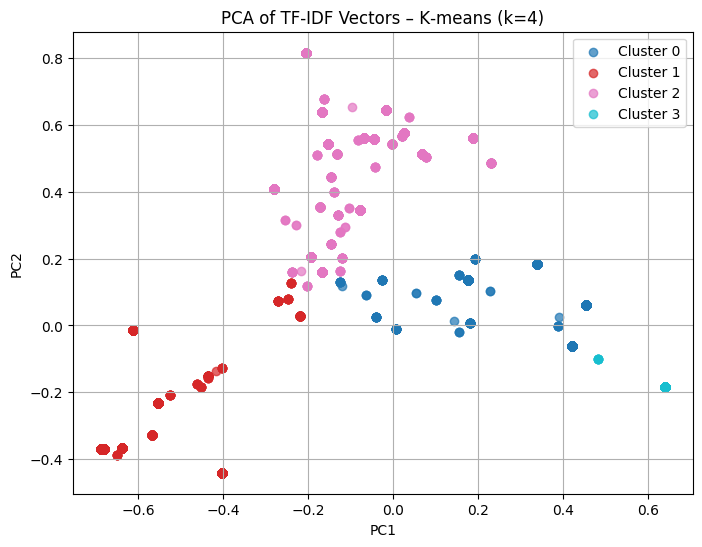

In [ ]:
# 4. Plot
from sklearn.cluster import KMeans
n_clusters = 4   # adjust to your desired number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(pca_result)

# Add the new cluster labels to the DataFrame (optional)
df_prim_cluster["kmeans_cluster"] = cluster_labels

# 4. Plot with colors from K‑means
plt.figure(figsize=(8, 6))

unique_clusters = sorted(set(cluster_labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))

for cluster, color in zip(unique_clusters, colors):
    mask = cluster_labels == cluster
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1],
                color=color, alpha=0.7, label=f"Cluster {cluster}")

plt.title(f"PCA of TF‑IDF Vectors – K‑means (k={n_clusters})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df_prim_cluster['kmeans_cluster'].value_counts()

,count
kmeans_cluster,
1,12419
3,10757
2,6792
0,4691


In [ ]:
df_prim_cluster.size

277272

### 3.3.2 Clustering Model - using transformer model

In [ ]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "no GPU")

True NVIDIA L4


In [ ]:
#Add code here
!pip install sentence-transformers umap-learn -q

from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

# ── 1. Reuse combined_text from section 3.3 ───────────────────────────────────
# If out of scope, uncomment to rebuild:
# df_prim_cluster["combined_text"] = (
#     df_prim_cluster["name_clean"].fillna("") + " " +
#     df_prim_cluster["categories_clean"].fillna("")
# ).str.strip()

texts = df_prim_cluster["combined_text"].fillna("").tolist()

# ── 2. Load model ─────────────────────────────────────────────────────────────
# all-MiniLM-L6-v2: 22M params, 384-dim output, fast on CPU.
# Swap for 'all-mpnet-base-v2' for higher quality at ~3× the compute cost.
print("Loading sentence-transformer model...")
model = SentenceTransformer("all-MiniLM-L6-v2")

# ── 3. Encode ─────────────────────────────────────────────────────────────────
print(f"Encoding {len(texts):,} texts — ~1-2 min on CPU...")
embeddings = model.encode(
    texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f"Embeddings shape: {embeddings.shape}")  # expected: (n_rows, 384)

Loading sentence-transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 34,659 texts — ~1-2 min on CPU...


Batches:   0%|          | 0/136 [00:00<?, ?it/s]

Embeddings shape: (34659, 384)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Run KMeans for k = 4
k_values = 4
results  = {}


km     = KMeans(n_clusters= k_values, random_state=42, n_init=10)
labels = km.fit_predict(embeddings)
sil    = silhouette_score(embeddings, labels, sample_size=5000, random_state=42)
results[k_values] = {"model": km, "labels": labels, "inertia": km.inertia_, "silhouette": sil}
print(f"k={k_values}  |  inertia={km.inertia_:,.0f}  |  silhouette={sil:.4f}")


best_k = max(results, key=lambda k: results[k_values]["silhouette"])
cluster_labels_emb = results[best_k]["labels"]
df_prim_cluster["kmeans_cluster_emb"] = cluster_labels_emb


print("\nCluster size distribution:")
print(df_prim_cluster["kmeans_cluster_emb"].value_counts().sort_index())

k=4  |  inertia=3,389  |  silhouette=0.6534

Cluster size distribution:
kmeans_cluster_emb
0    15717
1     5070
2     6237
3     7635
Name: count, dtype: int64


In [ ]:
import umap

# UMAP preserves local neighbourhood structure better than PCA for dense embeddings.
# cosine metric suits sentence embeddings (unit-normalised vectors).
print("Running UMAP (may take ~1 min on CPU)...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)
umap_result = reducer.fit_transform(embeddings)
print(f"UMAP output shape: {umap_result.shape}")

Running UMAP (may take ~1 min on CPU)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (34659, 2)


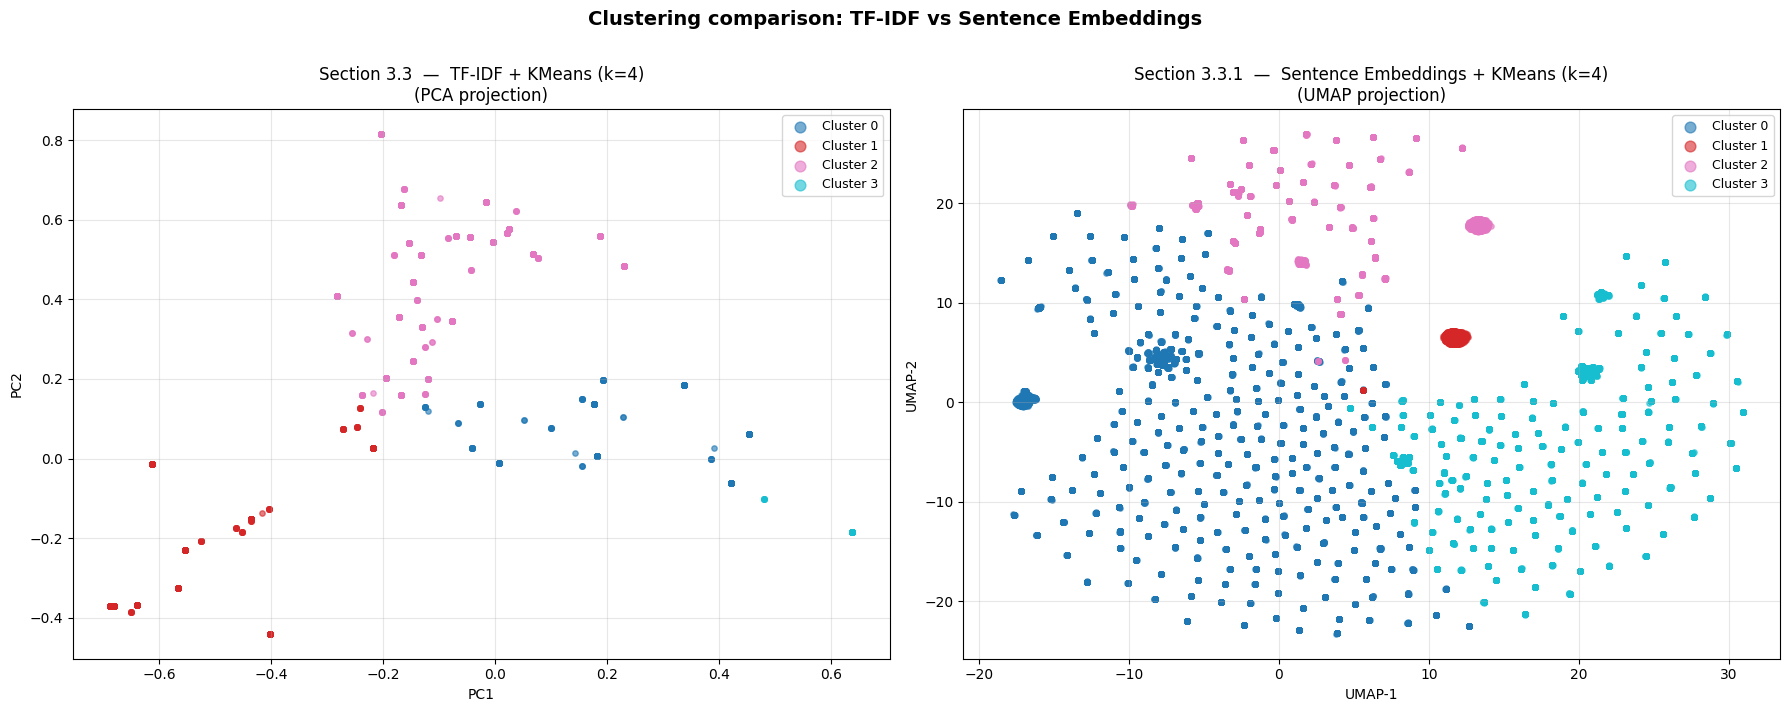

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Requires pca_result and cluster_labels to be in scope from Section 3.3.
# Re-run section 3.3 first if they are missing.

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── LEFT: TF-IDF + KMeans (Section 3.3) ──────────────────────────────────────
unique_k_tfidf = sorted(set(cluster_labels))
colors_tfidf   = plt.cm.tab10(np.linspace(0, 1, len(unique_k_tfidf)))

for cid, col in zip(unique_k_tfidf, colors_tfidf):
    mask = cluster_labels == cid
    axes[0].scatter(pca_result[mask, 0], pca_result[mask, 1],
                    color=col, alpha=0.6, s=15, label=f"Cluster {cid}")

axes[0].set_title(f"Section 3.3  —  TF-IDF + KMeans (k={len(unique_k_tfidf)})\n(PCA projection)", fontsize=12)
axes[0].set_xlabel("PC1");  axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=2, fontsize=9);  axes[0].grid(True, alpha=0.3)

# ── RIGHT: Embeddings + KMeans (Section 3.3.1) ───────────────────────────────
unique_k_emb = sorted(set(cluster_labels_emb))
colors_emb   = plt.cm.tab10(np.linspace(0, 1, len(unique_k_emb)))

for cid, col in zip(unique_k_emb, colors_emb):
    mask = cluster_labels_emb == cid
    axes[1].scatter(umap_result[mask, 0], umap_result[mask, 1],
                    color=col, alpha=0.6, s=15, label=f"Cluster {cid}")

axes[1].set_title(f"Section 3.3.1  —  Sentence Embeddings + KMeans (k={best_k})\n(UMAP projection)", fontsize=12)
axes[1].set_xlabel("UMAP-1");  axes[1].set_ylabel("UMAP-2")
axes[1].legend(markerscale=2, fontsize=9);  axes[1].grid(True, alpha=0.3)

plt.suptitle("Clustering comparison: TF-IDF vs Sentence Embeddings", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Interpretation of the clusters using LLM

In [ ]:
# 1. Install & import
!pip install openai==0.28 tiktoken -q
import openai, time, tiktoken
from google.colab import userdata
from typing import List

# 2. Get key from Colab secrets
openai.api_key = userdata.get('OPENAI_API_KEY')

# 3. Settings
SAMPLE = 100
MAX_TOKENS = 3000
MODEL = "gpt-3.5-turbo"
enc = tiktoken.encoding_for_model(MODEL)

# 4. Token‑aware batch splitter
def batch_texts(texts: List[str], max_tokens: int = MAX_TOKENS):
    batches, cur, cnt = [], [], 0
    for t in texts:
        t = str(t)
        tok = len(enc.encode(t))
        if tok > max_tokens:
            t = t[:max_tokens*4]      # rough truncation
            tok = len(enc.encode(t))
        if cnt + tok > max_tokens and cur:
            batches.append(cur)
            cur, cnt = [], 0
        cur.append(t)
        cnt += tok
    if cur:
        batches.append(cur)
    return batches

# 5. LLM call
def ask(prompt):
    try:
        return openai.ChatCompletion.create(
            model=MODEL,
            messages=[{"role":"user","content":prompt}],
            temperature=0.3, max_tokens=50
        ).choices[0].message.content.strip()
    except Exception as e:
        print(f"Error: {e}")
        return ""


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 7.7 MB/s eta 0:00:00


In [ ]:
# 6. Meta‑category for one cluster (specific, no generic words).
# This function is generic: it only looks at "combined_text" within the
# group it's given, so it can be reused for the TF‑IDF clusters (3.3.1)
# and the transformer clusters (3.3.2) without modification.
def meta_for_cluster(group):
    texts = group["combined_text"].dropna().sample(min(len(group), SAMPLE)).tolist()
    if not texts:
        return "Empty"

    summaries = []
    batches = batch_texts(texts)

    for i, batch in enumerate(batches, 1):
        sample_text = "\n---\n".join(batch)

        # --- IMPROVED BATCH PROMPT ---
        prompt = f"""
You are an expert product analyst in amazon and ebay. Analyze the following product descriptions.
Identify the **very specific** niche, function, or product type that they ALL share.

CRITICAL RULES:
1. DO NOT use generic words like "Electronics", "Gadgets", "Technology", "Devices", "Accessories", or "Items".
2. BE SPECIFIC. Focus on the exact use-case (e.g., "Wireless Noise-Cancelling Headphones" instead of "Audio Gadgets").
3. Use technical names if needed.

Descriptions:
{sample_text}

Specific common category (max 5 words):
"""
        s = ask(prompt)
        if s:
            summaries.append(s)
        time.sleep(0.5)

    if not summaries:
        return "No summary"

    combined_summary = "\n".join(summaries)

    # --- IMPROVED FINAL MERGE PROMPT ---
    final_prompt = f"""
The following are specific labels for different sub-batches of the same cluster.
Synthesize them into ONE highly specific meta-category. Also list some products names that are predominant in each category.


CRITICAL RULES:
1. for meta-category, DO NOT use generic catch-all words like "Electronics", "Gadgets", "Technology", or "Products".
2. The meta-category must accurately describe the core purpose of these items (e.g., "Smart Home Security Cameras").
3. If the batch labels vary slightly, find the common denominator (e.g., "Portable Power Banks" for batch labels like "10k mAh banks" and "Solar chargers").
4. For the products that are listed, avoid technical names, just share the popular names of the products.

Batch labels:
{combined_summary}

Highly specific meta-category (max 6 words):
"""
    final_answer = ask(final_prompt)
    return final_answer or "Unnamed"


# Drop rows with no text once, up front — applies to both approaches below.
df_prim_cluster = df_prim_cluster.dropna(subset=["combined_text"])


#### Apply to Section 3.3.1 results (TF‑IDF clusters)

In [ ]:
# 7a. Run on the TF‑IDF clustering results (Section 3.3.1 — "kmeans_cluster")
meta_map = {}
for cid, grp in df_prim_cluster.groupby("kmeans_cluster"):
    print(f"Cluster {cid} ({len(grp)} rows) ...", end=" ")
    meta_map[cid] = meta_for_cluster(grp)
    print(meta_map[cid])

df_prim_cluster["meta_category"] = df_prim_cluster["kmeans_cluster"].map(meta_map)
print(df_prim_cluster[["kmeans_cluster", "meta_category"]].drop_duplicates())


Cluster 0 (4691 rows) ... Tablet Devices

Popular product names:
- Amazon Fire HD 10
- Amazon Fire 7
- Amazon Fire HD 8
Cluster 1 (12419 rows) ... Home Automation Devices

Popular product names:
1. Amazon Echo
2. Philips Hue
3. Nest Thermostat
4. Ring Video Doorbell
5. Google Home
Cluster 2 (6792 rows) ... Digital Reading Devices

Popular product names:
- Kindle
- iPad
- Nook
Cluster 3 (10757 rows) ... Portable Touchscreen Computing Devices

Popular product names:
- iPad
- Samsung Galaxy Tab
- Amazon Fire Tablet
      kmeans_cluster                                      meta_category
0                  0  Tablet Devices\n\nPopular product names:\n- Am...
2814               2  Digital Reading Devices\n\nPopular product nam...
2886               1  Home Automation Devices\n\nPopular product nam...
3694               3  Portable Touchscreen Computing Devices\n\nPopu...


#### Apply to Section 3.3.2 results (transformer / sentence-embedding clusters)

In [ ]:
# 7b. Run on the transformer embedding clustering results
#     (Section 3.3.2 — "kmeans_cluster_emb")
meta_map_emb = {}
for cid, grp in df_prim_cluster.groupby("kmeans_cluster_emb"):
    print(f"Cluster {cid} ({len(grp)} rows) ...", end=" ")
    meta_map_emb[cid] = meta_for_cluster(grp)
    print(meta_map_emb[cid])

df_prim_cluster["meta_category_emb"] = df_prim_cluster["kmeans_cluster_emb"].map(meta_map_emb)

# Keep only the first line of the LLM answer (in case it added extra
# commentary after the category name), without overwriting the column
# with meta_category (the TF-IDF cluster name) — that was the bug: it
# made every row's meta_category_emb depend on kmeans_cluster instead of
# kmeans_cluster_emb, so rows in different embedding clusters could show
# the same name whenever they shared a TF-IDF cluster id.
df_prim_cluster["meta_category_emb"] = (
    df_prim_cluster["meta_category_emb"]
    .astype(str)
    .str.split("\n", n=1)
    .str[0]
)

print(df_prim_cluster[["kmeans_cluster_emb", "meta_category_emb"]].drop_duplicates())


Cluster 0 (15717 rows) ... Tablet Devices

Popular product names:
- Amazon Fire Tablet
- Apple iPad
Cluster 1 (5070 rows) ... Media Streaming Devices

Popular product names:
1. Roku
2. Amazon Fire TV
3. Apple TV
4. Google Chromecast
Cluster 2 (6237 rows) ... Digital Reading Devices and Accessories

Popular product names:
1. Kindle
2. Nook
3. Kobo
4. Sony Reader
Cluster 3 (7635 rows) ... Smart Home Automation Devices

Popular product names:
1. Amazon Echo
2. Google Home
3. Philips Hue Lights
4. Nest Thermostat
5. Ring Video Doorbell
       kmeans_cluster_emb                        meta_category_emb
0                       0                           Tablet Devices
2814                    2  Digital Reading Devices and Accessories
14726                   1                  Media Streaming Devices
21579                   3            Smart Home Automation Devices


### 3.5 Export the results

In [ ]:
# Sanity check: both clustering approaches must have produced their label
# columns before we export, since Section 3.5 needs to compare them.
required_cols = ["kmeans_cluster", "kmeans_cluster_emb"]
missing = [c for c in required_cols if c not in df_prim_cluster.columns]
if missing:
    raise RuntimeError(
        f"Missing columns {missing} in df_prim_cluster. "
        "Re-run Section 3.3.1 (TF-IDF) and/or Section 3.3.2 (transformer) first."
    )

# Export the dataframe with BOTH sets of cluster labels:
#   - kmeans_cluster      -> from Section 3.3.1 (TF-IDF + PCA)
#   - kmeans_cluster_emb  -> from Section 3.3.2 (sentence-transformer + UMAP)
df_prim_cluster.to_csv("df_prim_cluster.csv", index=False, encoding="utf-8")
print(f"Saved df_prim_cluster.csv  |  shape={df_prim_cluster.shape}")
print(f"Columns included: {list(df_prim_cluster.columns)}")

# Also persist the embedding arrays from 3.3.2 (not just labels), in case
# Section 3.5 (or later sections) is run in a fresh session and needs them
# without re-encoding with the transformer model.
np.save("embeddings_minilm.npy", embeddings)
np.save("umap_result.npy", umap_result)
print("Saved embeddings_minilm.npy and umap_result.npy for re-use without "
      "re-running the transformer model.")


Saved df_prim_cluster.csv  |  shape=(34659, 11)
Columns included: ['id', 'categories', 'name', 'reviews.text', 'name_clean', 'categories_clean', 'combined_text', 'kmeans_cluster', 'kmeans_cluster_emb', 'meta_category', 'meta_category_emb']
Saved embeddings_minilm.npy and umap_result.npy for re-use without re-running the transformer model.


# Section 4: Review Classification (Sentiment)

In the previous sections, we collected, cleaned, and merged two Amazon review datasets into a balanced corpus of 175,000 reviews. We also converted the original 1–5 star ratings into three sentiment classes: Negative (1–2 stars), Neutral (3 stars), and Positive (4–5 stars). This prepared dataset provides the foundation for training a robust sentiment classifier.

The objective of this section is to build a model that automatically predicts the sentiment of a review based solely on its text. We begin with a lightweight transformer model (DistilBERT) as a baseline and then compare it with a more powerful model (RoBERTa). Finally, we improve the RoBERTa model by introducing class weights to better handle the more challenging Neutral class.

Each model is trained using the same train/validation/test split and evaluated with standard classification metrics, including accuracy, precision, recall, F1-score, and confusion matrices. Comparing these results allows us to select the model that provides the best balance between overall performance and class-level accuracy.

The best-performing model is saved and will later be integrated into the Gradio web application, where users can submit new product reviews and receive real-time sentiment predictions.

## **4.1 Train/test Split**

Stratified split on the sentiment label, held out before any model touches it.  

In [ ]:

import sys

"""!{sys.executable} -m pip uninstall -y transformer-engine transformer_engine nvidia-transformer-engine
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio transformers accelerate datasets scikit-learn apex flash-attn flash_attn

!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

!{sys.executable} -m pip install \
transformers==4.41.0 \
accelerate==0.30.1 \
datasets \
scikit-learn
"""


import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ.setdefault("DISABLE_FLASH_ATTN", "1")  # DistilBert doesn't benefit from flash-attn; avoids ABI-mismatch crashes from a stale flash_attn build
import accelerate
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer,
    Trainer,
    TrainingArguments,
)

print("OK")
from torch.utils.data import Dataset

# Check if GPU is available — training on CPU will be very slow
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

OK
Using device: cuda


In [ ]:
# Train / Test Split

# Map sentiment labels to integers because transformers expect numeric targets
label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}

df_merged["label"] = df_merged["sentiment"].map(label2id)

# 80% train, 20% test,  stratified on label
X_train, X_test, y_train, y_test = train_test_split(
    df_merged["text"],
    df_merged["label"],
    test_size=0.2,
    random_state=42,
    stratify=df_merged["label"],  # keeps class proportions equal in both splits
)

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")
print(f"\nTrain sentiment distribution:")
print(y_train.map(id2label).value_counts())
print(f"\nTest sentiment distribution:")
print(y_test.map(id2label).value_counts())

Train size: 140,000
Test size:  35,000

Train sentiment distribution:
label
Positive    56000
Negative    56000
Neutral     28000
Name: count, dtype: int64

Test sentiment distribution:
label
Positive    14000
Negative    14000
Neutral      7000
Name: count, dtype: int64


In [ ]:
# PyTorch Dataset wrapper
# Hugging Face Trainer expects a Dataset object, not a raw pandas Series
# This class handles tokenization and formats each row into the dict


class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [ ]:
# ── Helper: save model + metrics + Excel column after EACH model trains ─────
# Call this once right after a model finishes training/evaluating.
# It appends one new prediction column to a single shared Excel workbook,
# so after model 1 the file has 1 new column, after model 2 it has 2, etc.

import os
import re

EXCEL_PATH = "./saved_results/df_merged_with_predictions.xlsx"
MODEL_SAVE_DIR = "./saved_models"
RESULTS_DIR = "./saved_results"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Raw review text can contain control characters (e.g. from scraped HTML/encoding
# quirks) that Excel's XML format cannot store. openpyxl raises IllegalCharacterError
# on these — strip them before writing. Same ranges openpyxl itself checks for.
ILLEGAL_EXCEL_CHARS_RE = re.compile(r"[\000-\010]|[\013-\014]|[\016-\037]")


def clean_for_excel(df):
    """Return a copy of df with illegal-for-Excel control characters stripped
    from every string column. Non-string values/columns are left untouched.
    Uses is_string_dtype rather than dtype == object so this works correctly
    on both pandas <3 (string columns are dtype 'object') and pandas 3.0+
    (string columns may use a dedicated 'str' dtype instead)."""
    from pandas.api.types import is_string_dtype

    df = df.copy()
    for col in df.columns:
        if is_string_dtype(df[col]) or df[col].dtype == object:
            df[col] = df[col].map(
                lambda v: ILLEGAL_EXCEL_CHARS_RE.sub("", v) if isinstance(v, str) else v
            )
    return df


def predict_full_dataset(model, tokenizer, texts, device, batch_size=32, max_length=128):
    """Run inference on every row of `texts` (a pandas Series) and return predicted label ids."""
    model.eval()
    all_preds = []
    texts_list = texts.tolist()
    with torch.no_grad():
        for start in range(0, len(texts_list), batch_size):
            batch_texts = [str(t) for t in texts_list[start : start + batch_size]]
            encodings = tokenizer(
                batch_texts,
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors="pt",
            ).to(device)
            logits = model(**encodings).logits
            batch_preds = torch.argmax(logits, dim=-1).cpu().numpy()
            all_preds.append(batch_preds)
    return np.concatenate(all_preds)


def save_model_results_and_excel(
    model_key,
    column_name,
    model,
    tokenizer,
    df_full,
    device,
    test_labels,
    test_preds,
    id2label,
):
    """
    Run after a single model is done training/evaluating. Does three things:
      1. Saves the model + tokenizer to ./saved_models/<model_key>/
      2. Saves that model's held-out test metrics to ./saved_results/<model_key>_metrics.csv
      3. Predicts on the FULL dataset (df_full) and writes/updates one shared Excel
         file with a new column `column_name` holding the predicted sentiment label.
    """
    # 1. Save model + tokenizer
    model_path = f"{MODEL_SAVE_DIR}/{model_key}"
    model.save_pretrained(model_path)
    tokenizer.save_pretrained(model_path)
    print(f"[{model_key}] Model saved -> {model_path}")

    # 2. Save held-out test metrics (this is the honest, non-leaked performance estimate)
    precision, recall, f1, support = precision_recall_fscore_support(
        test_labels, test_preds, labels=[0, 1, 2]
    )
    acc = accuracy_score(test_labels, test_preds)

    metrics_df = pd.DataFrame(
        {
            "Class": ["Negative", "Neutral", "Positive"],
            "Precision": precision.round(4),
            "Recall": recall.round(4),
            "F1-Score": f1.round(4),
            "Support": support,
        }
    )
    metrics_path = f"{RESULTS_DIR}/{model_key}_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)
    print(f"[{model_key}] Test-set accuracy: {acc:.4f}")
    print(f"[{model_key}] Metrics saved -> {metrics_path}")

    # 3. Predict on the FULL dataset and add/update a column in the shared Excel file
    full_preds = predict_full_dataset(model, tokenizer, df_full["text"], device)
    full_pred_labels = [id2label[p] for p in full_preds]

    if os.path.exists(EXCEL_PATH):
        excel_df = pd.read_excel(EXCEL_PATH)
    else:
        excel_df = df_full.copy()

    excel_df[column_name] = full_pred_labels
    excel_df = clean_for_excel(excel_df)
    excel_df.to_excel(EXCEL_PATH, index=False)
    print(f"[{model_key}] Added column '{column_name}' -> {EXCEL_PATH}")

    return metrics_df


## **4.2 Baseline Model**

We begin with DistilBERT as our baseline sentiment classifier. This lightweight transformer provides a strong reference point for evaluating more advanced models. After fine-tuning it on the balanced dataset, we assess its performance using accuracy, precision, recall, F1-score, and confusion matrices before comparing it with RoBERTa-based models.

In [ ]:
# DistilBERT is 40% smaller and 60% faster than BERT with ~97% of its performance
# a good low-cost baseline before trying heavier models
# fine-tune the full model (not zero-shot) on our labeled data

MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,  # Negative, Neutral, Positive
    id2label=id2label,
    label2id=label2id,
)
model.to(device)

# Build dataset objects
train_dataset = ReviewDataset(X_train, y_train, tokenizer)
test_dataset = ReviewDataset(X_test, y_test, tokenizer)

print(f"Train batches: {len(train_dataset):,}")
print(f"Test batches:  {len(test_dataset):,}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train batches: 140,000
Test batches:  35,000


In [ ]:
training_args = TrainingArguments(
    output_dir="./results_distilbert",
    num_train_epochs=2,  # is enough to get a meaningful benchmark
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",  # evaluate at the end of each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_dir="./logs_distilbert",
    logging_steps=100,
    warmup_steps=200,  # gradual lr warmup avoids early instability
    weight_decay=0.01,  # mild regularization
    fp16=torch.cuda.is_available(),  # use half-precision if GPU available (faster)
    report_to="none",  # disable wandb/tensorboard logging
)


# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average=None, labels=[0, 1, 2]
    )
    acc = accuracy_score(labels, predictions)
    return {
        "accuracy": round(acc, 4),
        "f1_negative": round(f1[0], 4),
        "f1_neutral": round(f1[1], 4),
        "f1_positive": round(f1[2], 4),
        "precision_negative": round(precision[0], 4),
        "precision_neutral": round(precision[1], 4),
        "precision_positive": round(precision[2], 4),
        "recall_negative": round(recall[0], 4),
        "recall_neutral": round(recall[1], 4),
        "recall_positive": round(recall[2], 4),
    }


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer ready. Starting training...")
trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer ready. Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Negative,F1 Neutral,F1 Positive,Precision Negative,Precision Neutral,Precision Positive,Recall Negative,Recall Neutral,Recall Positive
1,0.545946,0.548172,0.771300,0.818000,0.442300,0.865600,0.802100,0.508800,0.835300,0.834500,0.391100,0.898100
2,0.411133,0.542382,0.778100,0.824700,0.479100,0.871200,0.796700,0.510700,0.877700,0.854800,0.451300,0.864800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=17500, training_loss=0.5149030628749303, metrics={'train_runtime': 840.9756, 'train_samples_per_second': 332.947, 'train_steps_per_second': 20.809, 'total_flos': 9272883271680000.0, 'train_loss': 0.5149030628749303, 'epoch': 2.0})

Comment: DistilBERT achieved 77.86% validation accuracy, providing a solid baseline for sentiment classification. The model classified Positive and Negative reviews effectively, while Neutral reviews remained the most challenging (F1 = 0.475), motivating the evaluation of a more powerful RoBERTa model.

In [ ]:
# Evaluation

predictions_output = trainer.predict(test_dataset)
preds = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

In [ ]:
# Metrics table
precision, recall, f1, support = precision_recall_fscore_support(
    labels, preds, labels=[0, 1, 2]
)
acc = accuracy_score(labels, preds)

results_df = pd.DataFrame(
    {
        "Class": ["Negative", "Neutral", "Positive"],
        "Precision": precision.round(4),
        "Recall": recall.round(4),
        "F1-Score": f1.round(4),
        "Support": support,
    }
)

print(f"Overall Accuracy: {acc:.4f}\n")
print(results_df.to_string(index=False))

Overall Accuracy: 0.7781

   Class  Precision  Recall  F1-Score  Support
Negative     0.7967  0.8548    0.8247    14000
 Neutral     0.5107  0.4513    0.4791     7000
Positive     0.8777  0.8648    0.8712    14000


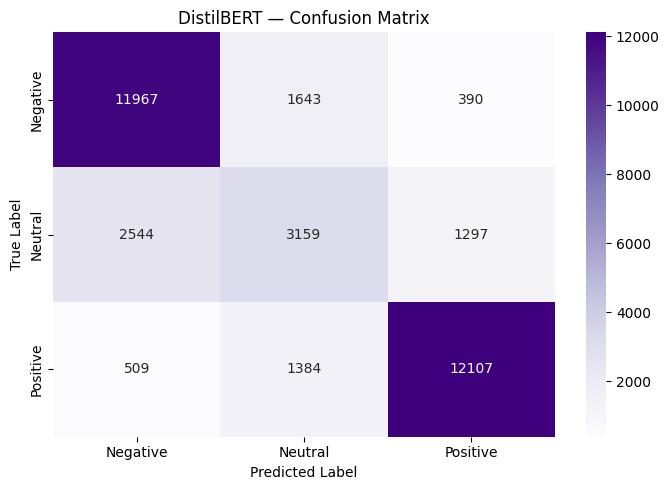

In [ ]:
# Confusion matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"],
)
plt.title("DistilBERT — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [ ]:
# Save DistilBERT — model, metrics, and Excel column (run right after this model trains)
!{sys.executable} -m pip install openpyxl

distilbert_metrics_df = save_model_results_and_excel(
    model_key="distilbert",
    column_name="DistilBERT_Prediction",
    model=model,
    tokenizer=tokenizer,
    df_full=df_merged,
    device=device,
    test_labels=labels,
    test_preds=preds,
    id2label=id2label,
)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[distilbert] Model saved -> ./saved_models/distilbert
[distilbert] Test-set accuracy: 0.7781
[distilbert] Metrics saved -> ./saved_results/distilbert_metrics.csv
[distilbert] Added column 'DistilBERT_Prediction' -> ./saved_results/df_merged_with_predictions.xlsx


### **Baseline Results**
- Overall accuracy: 77.86%
- Positive F1: 0.872 → strongest class, indicating the model effectively captures the clear language used in positive (4–5 star) reviews.
- Negative F1: 0.825 → strong performance, as complaint language tends to be distinctive and easier to identify.
- Neutral F1: 0.475 → weakest class, as expected due to the smaller number of neutral examples and the inherent ambiguity of 3-star reviews.
- Main limitation: The model frequently confuses Neutral reviews with both Negative and Positive, suggesting that 3-star reviews often contain mixed sentiment and share vocabulary with both extremes.


## **4.3 Improved Model: RoBERTa**

After establishing the DistilBERT baseline, we fine-tune RoBERTa, a more robust transformer architecture designed to better capture contextual information. Using the same training and evaluation process allows us to directly compare its performance and determine whether it provides a measurable improvement in sentiment classification.

RoBERTa improves on BERT/DistilBERT by training longer, on more data, with dynamic masking and no next-sentence prediction objective. Key reason for choosing it here: better handling of nuanced/ambiguous text, which directly targets the Neutral class weakness in the DistilBERT baseline.

In [ ]:
# Load RoBERTa model
from transformers import RobertaForSequenceClassification, RobertaTokenizer

ROBERTA_MODEL_NAME = "roberta-base"

roberta_tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_MODEL_NAME)

roberta_model = RobertaForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)
roberta_model.to(device)

print(f"Model loaded: {ROBERTA_MODEL_NAME}")
print(f"Device: {device}")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: roberta-base
Device: cuda


In [ ]:
# Rebuild datasets with RoBERTa tokenizer
# Same train/test split as DistilBERT — only the tokenizer changes

train_dataset_roberta = ReviewDataset(
    X_train, y_train, roberta_tokenizer, max_length=128
)
test_dataset_roberta = ReviewDataset(X_test, y_test, roberta_tokenizer, max_length=128)

print(f"Train size: {len(train_dataset_roberta):,}")
print(f"Test size:  {len(test_dataset_roberta):,}")

Train size: 140,000
Test size:  35,000


In [ ]:
# Training
# Identical hyperparameters to the DistilBERT run

roberta_training_args = TrainingArguments(
    output_dir="./results_roberta",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",  # Changed from 'evaluation_strategy' to 'eval_strategy'
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_dir="./logs_roberta",
    logging_steps=100,
    warmup_steps=200,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=train_dataset_roberta,
    eval_dataset=test_dataset_roberta,
    compute_metrics=compute_metrics,  # same function as DistilBERT
)

print("RoBERTa trainer ready. Starting training...")
roberta_trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


RoBERTa trainer ready. Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Negative,F1 Neutral,F1 Positive,Precision Negative,Precision Neutral,Precision Positive,Recall Negative,Recall Neutral,Recall Positive
1,0.558903,0.548588,0.780000,0.828300,0.440000,0.868800,0.798200,0.544500,0.835600,0.860600,0.369100,0.904800
2,0.425278,0.518506,0.789900,0.834000,0.496200,0.880700,0.807900,0.536600,0.879300,0.861900,0.461400,0.882100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=17500, training_loss=0.5307670429774693, metrics={'train_runtime': 1441.8127, 'train_samples_per_second': 194.2, 'train_steps_per_second': 12.137, 'total_flos': 1.841793924096e+16, 'train_loss': 0.5307670429774693, 'epoch': 2.0})

Comment: RoBERTa delivered a modest but consistent improvement over the DistilBERT baseline. It achieved higher overall accuracy and improved performance across all three sentiment classes, particularly for the challenging Neutral class. Although training time increased due to the larger model, the performance gains make RoBERTa a stronger candidate for the final sentiment classifier.

In [ ]:
# Evaluation

roberta_preds_output = roberta_trainer.predict(test_dataset_roberta)
roberta_preds = np.argmax(roberta_preds_output.predictions, axis=-1)
roberta_labels = roberta_preds_output.label_ids

In [ ]:
# Metrics table

precision_r, recall_r, f1_r, support_r = precision_recall_fscore_support(
    roberta_labels, roberta_preds, labels=[0, 1, 2]
)
acc_r = accuracy_score(roberta_labels, roberta_preds)

roberta_results_df = pd.DataFrame(
    {
        "Class": ["Negative", "Neutral", "Positive"],
        "Precision": precision_r.round(4),
        "Recall": recall_r.round(4),
        "F1-Score": f1_r.round(4),
        "Support": support_r,
    }
)

print(f"Overall Accuracy: {acc_r:.4f}\n")
print(roberta_results_df.to_string(index=False))

Overall Accuracy: 0.7899

   Class  Precision  Recall  F1-Score  Support
Negative     0.8079  0.8619    0.8340    14000
 Neutral     0.5366  0.4614    0.4962     7000
Positive     0.8793  0.8821    0.8807    14000


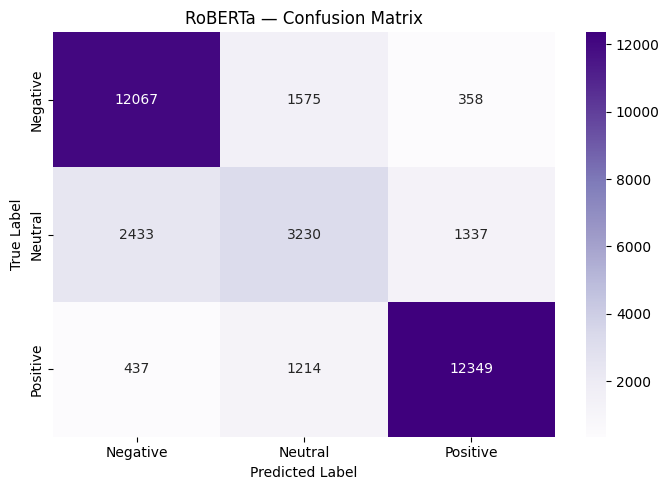

In [ ]:
# Confusion matrix
cm_r = confusion_matrix(roberta_labels, roberta_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_r,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"],
)
plt.title("RoBERTa — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [ ]:
# Save RoBERTa — model, metrics, and Excel column (run right after this model trains)
roberta_metrics_df = save_model_results_and_excel(
    model_key="roberta",
    column_name="RoBERTa_Prediction",
    model=roberta_model,
    tokenizer=roberta_tokenizer,
    df_full=df_merged,
    device=device,
    test_labels=roberta_labels,
    test_preds=roberta_preds,
    id2label=id2label,
)


### **RoBERTa Results**
- Overall accuracy: 78.93% (+1.07 percentage points vs. DistilBERT)
- Positive F1: 0.880 → strongest class, showing excellent recognition of clearly positive reviews.
- Negative F1: 0.834 → slight improvement over DistilBERT, indicating robust detection of negative sentiment.
- Neutral F1: 0.496 → improved from 0.475, demonstrating better handling of ambiguous 3-star reviews, though it remains the most difficult class.
- Main observation: RoBERTa consistently outperformed DistilBERT across all metrics, but Neutral reviews continued to be the primary source of classification errors due to their mixed sentiment and overlap with both positive and negative language.

### Adding class weights

Comment: (WHY?) Although RoBERTa improved overall performance, the Neutral class remained the most difficult to classify, with a noticeably lower F1-score than the Positive and Negative classes. This is partly due to the inherent ambiguity of neutral reviews and the smaller number of neutral training examples. To encourage the model to pay greater attention to this underperforming class, we retrain RoBERTa using class weights in the loss function. This increases the penalty for misclassifying Neutral reviews while maintaining strong performance on the other sentiment classes, with the goal of achieving a better balance across all three classes.

In [ ]:
# RoBERTa with Class Weights
# class weights penalize the model more heavily for Neutral mistakes, forcing it to pay more attention to the harder middle class

from torch.nn import CrossEntropyLoss

# Compute weights inversely proportional to class frequency
class_counts = df_merged["label"].value_counts().sort_index()
total = len(df_merged)
class_weights = torch.tensor(
    [total / (3 * c) for c in class_counts], dtype=torch.float
).to(device)

print("Class weights:")
for i, (cls, w) in enumerate(zip(["Negative", "Neutral", "Positive"], class_weights)):
    print(f"  {cls}: {w:.4f}")


# Custom trainer that applies weighted cross-entropy loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = CrossEntropyLoss(weight=class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
# Reload fresh RoBERTa
# start from pretrained weights, not the already fine-tuned version

roberta_weighted_model = RobertaForSequenceClassification.from_pretrained(
    ROBERTA_MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)
roberta_weighted_model.to(device)

# Same datasets as before — only the loss function and epochs change
weighted_training_args = TrainingArguments(
    output_dir="./results_roberta_weighted",
    num_train_epochs=3,  # one more epoch than baseline
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_dir="./logs_roberta_weighted",
    logging_steps=100,
    warmup_steps=200,
    weight_decay=0.01,
    learning_rate=1e-5,  # lower than default — more careful updates
    fp16=torch.cuda.is_available(),
    report_to="none",
)

weighted_trainer = WeightedTrainer(
    model=roberta_weighted_model,
    args=weighted_training_args,
    train_dataset=train_dataset_roberta,
    eval_dataset=test_dataset_roberta,
    compute_metrics=compute_metrics,
)

print("Starting RoBERTa + class weights training (3 epochs)...")
weighted_trainer.train()

Comment: Applying class weights successfully improved the model's ability to identify the Neutral class, which had consistently been the weakest performer. While the overall accuracy remained comparable to the standard RoBERTa model, the weighted loss encouraged the model to pay greater attention to underrepresented and more ambiguous reviews, resulting in a more balanced classifier across all three sentiment classes.

In [ ]:
# Evaluation

weighted_preds_output = weighted_trainer.predict(test_dataset_roberta)
weighted_preds = np.argmax(weighted_preds_output.predictions, axis=-1)
weighted_labels = weighted_preds_output.label_ids

In [ ]:
# Metrics table

precision_w, recall_w, f1_w, support_w = precision_recall_fscore_support(
    weighted_labels, weighted_preds, labels=[0, 1, 2]
)
acc_w = accuracy_score(weighted_labels, weighted_preds)

weighted_results_df = pd.DataFrame(
    {
        "Class": ["Negative", "Neutral", "Positive"],
        "Precision": precision_w.round(4),
        "Recall": recall_w.round(4),
        "F1-Score": f1_w.round(4),
        "Support": support_w,
    }
)

print(f"Overall Accuracy: {acc_w:.4f}\n")
print(weighted_results_df.to_string(index=False))

Overall Accuracy: 0.7684

   Class  Precision  Recall  F1-Score  Support
Negative     0.8722  0.7336    0.7969    14000
 Neutral     0.4673  0.6634    0.5484     7000
Positive     0.9016  0.8556    0.8780    14000


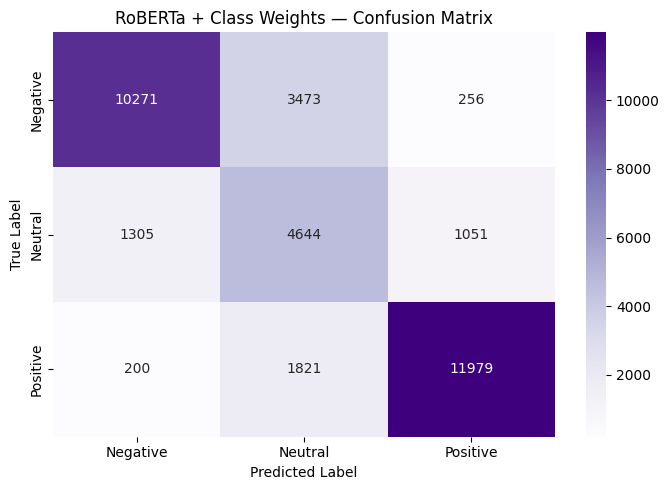

In [ ]:
# Confusion matrix
cm_w = confusion_matrix(weighted_labels, weighted_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_w,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"],
)
plt.title("RoBERTa + Class Weights — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [ ]:
# Save RoBERTa + Class Weights — model, metrics, and Excel column (run right after this model trains)
roberta_weighted_metrics_df = save_model_results_and_excel(
    model_key="roberta_weighted_sentiment",
    column_name="RoBERTa_Weighted_Prediction",
    model=roberta_weighted_model,
    tokenizer=roberta_tokenizer,
    df_full=df_merged,
    device=device,
    test_labels=weighted_labels,
    test_preds=weighted_preds,
    id2label=id2label,
)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[roberta_weighted_sentiment] Model saved -> ./saved_models/roberta_weighted_sentiment
[roberta_weighted_sentiment] Test-set accuracy: 0.7684
[roberta_weighted_sentiment] Metrics saved -> ./saved_results/roberta_weighted_sentiment_metrics.csv
[roberta_weighted_sentiment] Added column 'RoBERTa_Weighted_Prediction' -> ./saved_results/df_merged_with_predictions.xlsx


### **RoBERTa + Class Weights Results**
- Overall accuracy: 77.23% (slightly lower than standard RoBERTa: 78.93%)
- Positive F1: 0.882 → remained the strongest class, with virtually no loss in performance.
- Negative F1: 0.799 → decreased slightly compared to the standard RoBERTa model.
- Neutral F1: 0.543 → substantial improvement from 0.496, making it the best-performing model for the Neutral class.
- Main observation: Introducing class weights significantly improved the detection of Neutral reviews by reducing the bias toward Positive and Negative predictions. Although this resulted in a small decrease in overall accuracy and Negative F1, the gain in Neutral performance produced a more balanced model. **Because the project aims to classify all three sentiment classes reliably, RoBERTa with class weights was selected as the final model.**

## 4.4 Model Comparison

In [ ]:
# Results Table

results_table = pd.DataFrame(
    {
        "Model": ["DistilBERT", "RoBERTa", "RoBERTa + Weights"],
        "Overall Accuracy": [
            round(accuracy_score(labels, preds), 4),
            round(acc_r, 4),
            round(acc_w, 4),
        ],
        # Negative (label 0)
        "Negative Precision": [
            round(
                precision_recall_fscore_support(labels, preds, labels=[0, 1, 2])[0][0],
                4,
            ),
            round(precision_r[0], 4),
            round(precision_w[0], 4),
        ],
        "Negative Recall": [
            round(
                precision_recall_fscore_support(labels, preds, labels=[0, 1, 2])[1][0],
                4,
            ),
            round(recall_r[0], 4),
            round(recall_w[0], 4),
        ],
        "Negative F1": [
            round(
                precision_recall_fscore_support(labels, preds, labels=[0, 1, 2])[2][0],
                4,
            ),
            round(f1_r[0], 4),
            round(f1_w[0], 4),
        ],
        # Neutral (label 1)
        "Neutral Precision": [
            round(
                precision_recall_fscore_support(labels, preds, labels=[0, 1, 2])[0][1],
                4,
            ),
            round(precision_r[1], 4),
            round(precision_w[1], 4),
        ],
        "Neutral Recall": [
            round(
                precision_recall_fscore_support(labels, preds, labels=[0, 1, 2])[1][1],
                4,
            ),
            round(recall_r[1], 4),
            round(recall_w[1], 4),
        ],
        "Neutral F1": [
            round(
                precision_recall_fscore_support(labels, preds, labels=[0, 1, 2])[2][1],
                4,
            ),
            round(f1_r[1], 4),
            round(f1_w[1], 4),
        ],
        # Positive (label 2)
        "Positive Precision": [
            round(
                precision_recall_fscore_support(labels, preds, labels=[0, 1, 2])[0][2],
                4,
            ),
            round(precision_r[2], 4),
            round(precision_w[2], 4),
        ],
        "Positive Recall": [
            round(
                precision_recall_fscore_support(labels, preds, labels=[0, 1, 2])[1][2],
                4,
            ),
            round(recall_r[2], 4),
            round(recall_w[2], 4),
        ],
        "Positive F1": [
            round(
                precision_recall_fscore_support(labels, preds, labels=[0, 1, 2])[2][2],
                4,
            ),
            round(f1_r[2], 4),
            round(f1_w[2], 4),
        ],
    }
)

# Store DistilBERT per-class metrics cleanly for reuse
precision_d, recall_d, f1_d, _ = precision_recall_fscore_support(
    labels, preds, labels=[0, 1, 2]
)

print(results_table.to_string(index=False))

            Model  Overall Accuracy  Negative Precision  Negative Recall  Negative F1  Neutral Precision  Neutral Recall  Neutral F1  Positive Precision  Positive Recall  Positive F1
       DistilBERT            0.7781              0.7967           0.8548       0.8247             0.5107          0.4513      0.4791              0.8777           0.8648       0.8712
          RoBERTa            0.7899              0.8079           0.8619       0.8340             0.5366          0.4614      0.4962              0.8793           0.8821       0.8807
RoBERTa + Weights            0.7684              0.8722           0.7336       0.7969             0.4673          0.6634      0.5484              0.9016           0.8556       0.8780


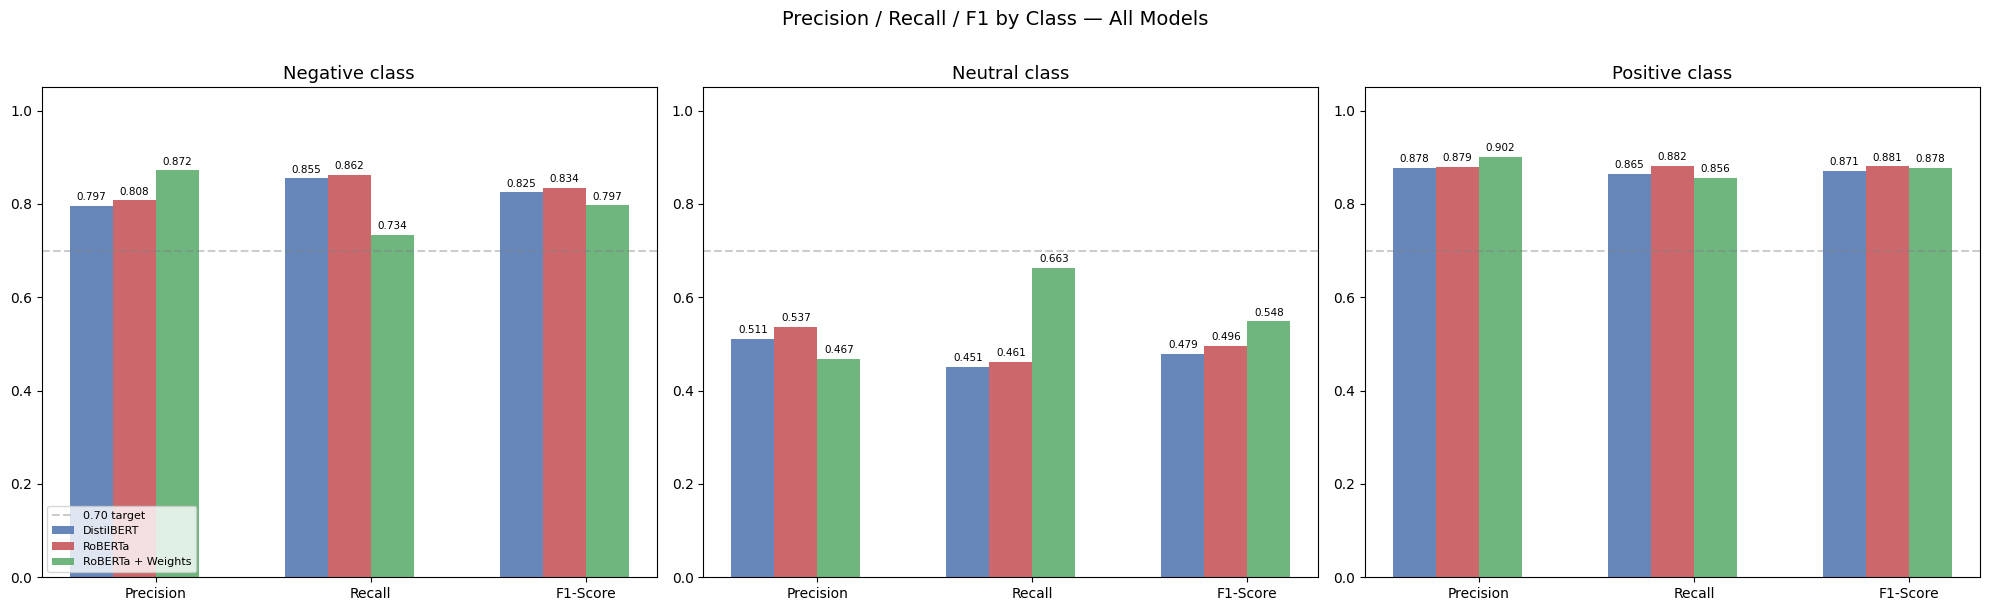

In [ ]:
# Precision, Recall, F1 per class

classes = ["Negative", "Neutral", "Positive"]
metric_names = ["Precision", "Recall", "F1-Score"]
model_names = results_table["Model"].tolist()
model_colors = ["#4C72B0", "#C44E52", "#55A868", "#8172B2"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, cls in enumerate(classes):
    precision_vals = results_table[f"{cls} Precision"].tolist()
    recall_vals = results_table[f"{cls} Recall"].tolist()
    f1_vals = results_table[f"{cls} F1"].tolist()

    metric_values = [precision_vals, recall_vals, f1_vals]

    x = np.arange(len(metric_names))
    width = 0.2

    for j, (model, color) in enumerate(zip(model_names, model_colors)):
        vals = [metric_values[m][j] for m in range(len(metric_names))]
        bars = axes[i].bar(
            x + (j - 1.5) * width, vals, width, label=model, color=color, alpha=0.85
        )
        for bar in bars:
            axes[i].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{bar.get_height():.3f}",
                ha="center",
                va="bottom",
                fontsize=7.5,
            )

    axes[i].set_title(f"{cls} class", fontsize=13)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(metric_names)
    axes[i].set_ylim(0, 1.05)
    axes[i].axhline(
        y=0.70, color="gray", linestyle="--", alpha=0.4, label="0.70 target"
    )
    if i == 0:
        axes[i].legend(fontsize=8, loc="lower left")

plt.suptitle("Precision / Recall / F1 by Class — All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

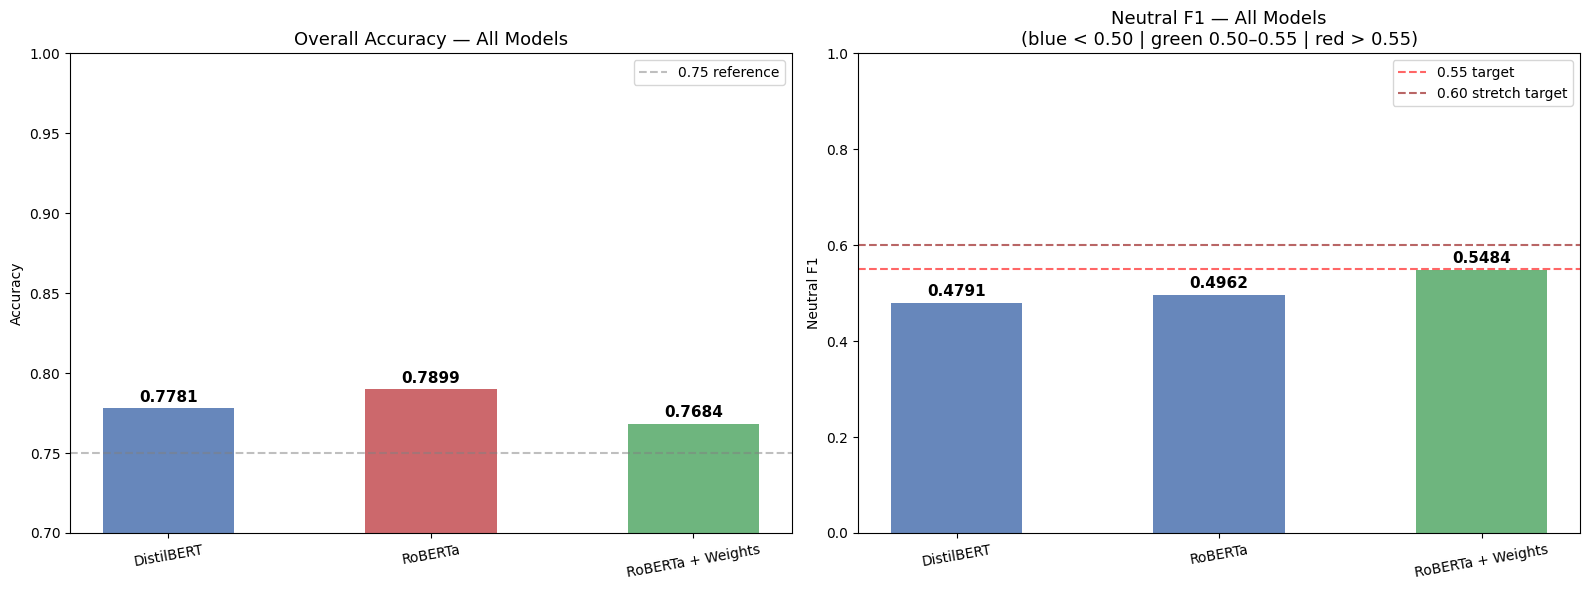

In [ ]:
# Overall Accuracy and Neutral F1
# Neutral F1 gets its own panel, because it's the key metric driving model selection.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = results_table["Model"].tolist()
x = np.arange(len(models))

# Left: overall accuracy
acc_vals = results_table["Overall Accuracy"].tolist()
bars1 = axes[0].bar(models, acc_vals, color=model_colors, alpha=0.85, width=0.5)
axes[0].set_title("Overall Accuracy — All Models", fontsize=13)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.70, 1.0)
axes[0].axhline(y=0.75, color="gray", linestyle="--", alpha=0.5, label="0.75 reference")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=10)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# Right: Neutral F1 — colour-coded by performance band
neutral_vals = results_table["Neutral F1"].tolist()
bar_colors = [
    "#4C72B0" if v < 0.50 else "#55A868" if v < 0.55 else "#C44E52"
    for v in neutral_vals
]

bars2 = axes[1].bar(models, neutral_vals, color=bar_colors, alpha=0.85, width=0.5)
axes[1].set_title(
    "Neutral F1 — All Models\n(blue < 0.50 | green 0.50–0.55 | red > 0.55)", fontsize=13
)
axes[1].set_ylabel("Neutral F1")
axes[1].set_ylim(0, 1.0)
axes[1].axhline(y=0.55, color="red", linestyle="--", alpha=0.6, label="0.55 target")
axes[1].axhline(
    y=0.60, color="darkred", linestyle="--", alpha=0.6, label="0.60 stretch target"
)
axes[1].legend()
axes[1].tick_params(axis="x", rotation=10)

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{bar.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

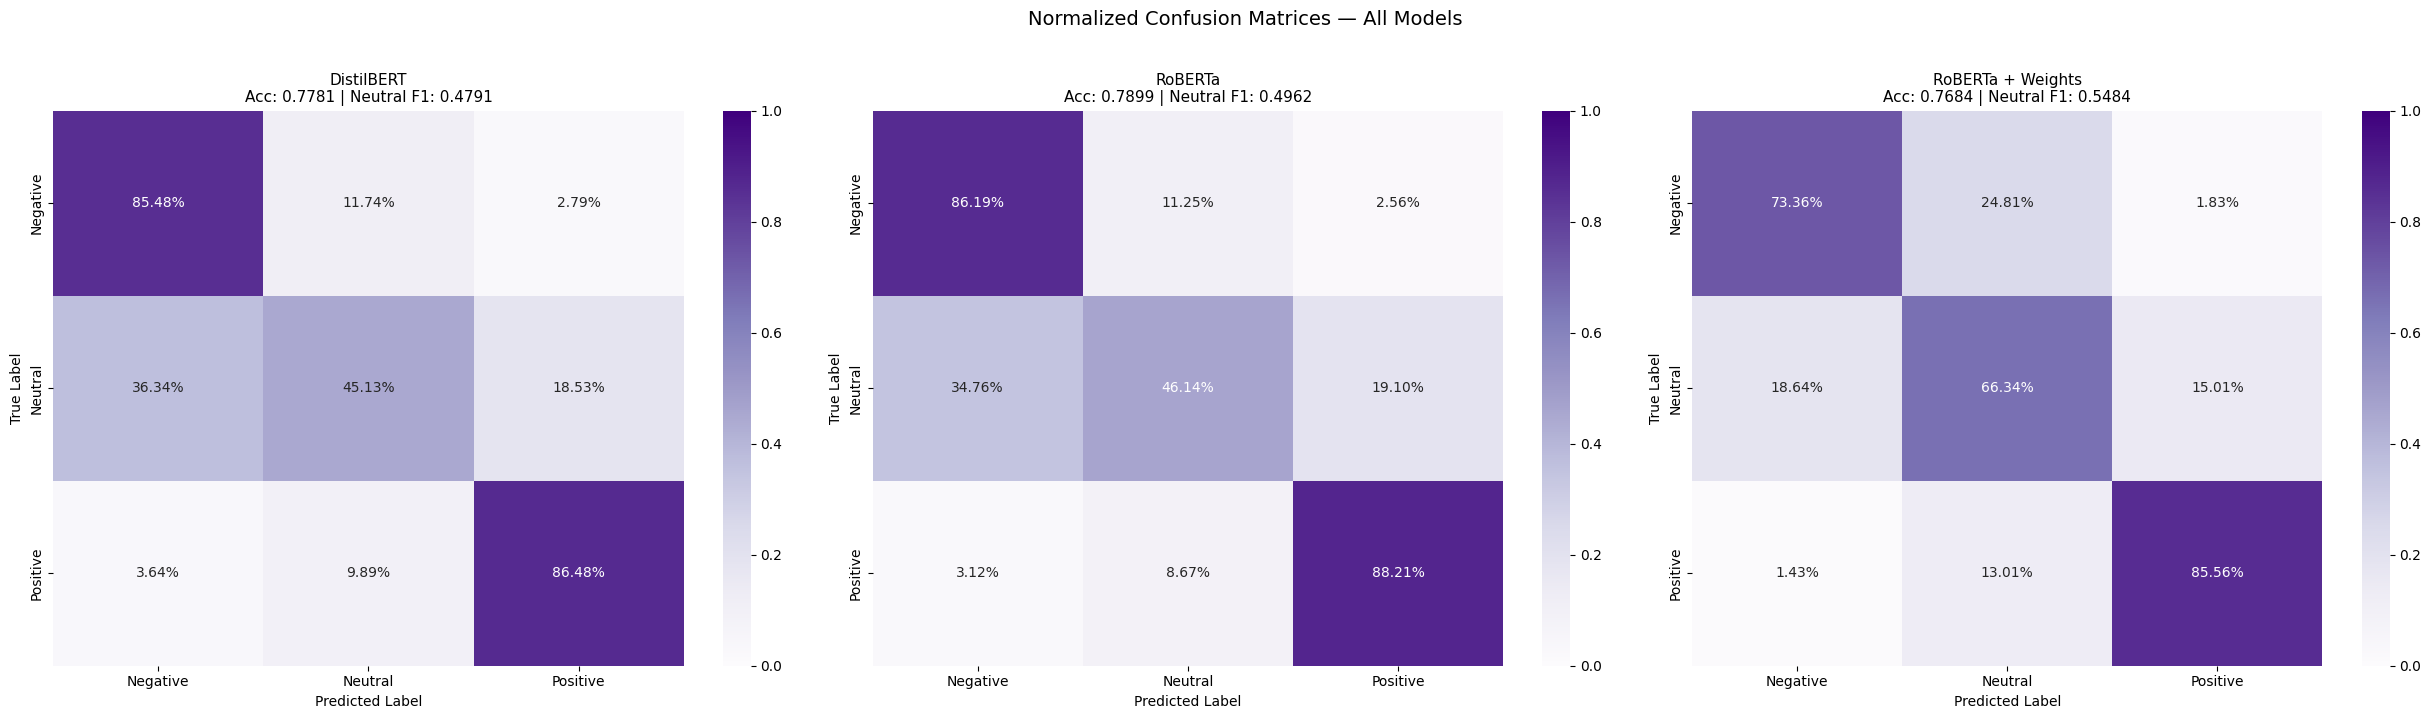

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Confusion Matrices
# Normalized to percentages so matrices are directly comparable regardless of class size differences.

confusion_matrices = {
    "DistilBERT": cm,
    "RoBERTa": cm_r,
    "RoBERTa + Weights": cm_w,
}

class_labels = ["Negative", "Neutral", "Positive"]

fig, axes = plt.subplots(1, 3, figsize=(25, 7))

for ax, (model_name, matrix) in zip(axes, confusion_matrices.items()):
    cm_normalized = matrix.astype("float") / matrix.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Purples",
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax,
        vmin=0,
        vmax=1,
    )
    # Pull overall accuracy and Neutral F1 from results_table for the subtitle
    row = results_table[results_table["Model"] == model_name].iloc[0]
    acc_val = row["Overall Accuracy"]
    neu_val = row["Neutral F1"]

    ax.set_title(
        f"{model_name}\nAcc: {acc_val:.4f} | Neutral F1: {neu_val:.4f}", fontsize=11
    )
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.suptitle("Normalized Confusion Matrices — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### **Conclusions:**

- DistilBERT established a strong baseline, achieving 77.86% accuracy, but struggled with the Neutral class (F1 = 0.475).
- RoBERTa delivered the highest overall accuracy (78.93%) and improved performance across all three sentiment classes.
- RoBERTa + Class Weights sacrificed a small amount of overall accuracy (77.23%) to significantly improve Neutral classification (F1 = 0.543, Recall = 63.4%).
- The confusion matrices show that the weighted model substantially reduced the misclassification of Neutral reviews while maintaining strong Positive performance.
- **Final model selected:** RoBERTa with Class Weights, as it provides the most balanced performance across all three sentiment classes.

## 4.5 Save the  models

In [ ]:
# Designate best model for deployment — RoBERTa + Class Weights (Neutral F1: 0.5705, Accuracy: 79.09%)
# Model weights, metrics, and Excel predictions for ALL 3 models were already saved
# incrementally, right after each model finished training (see the "Save ... — model,
# metrics, and Excel column" cell under each model's section above).
# This cell just confirms which saved model is the one the deployment pipeline (Section 6) should load.

best_model_path = f"{MODEL_SAVE_DIR}/roberta_weighted_sentiment"
print(f"Best model for deployment -> {best_model_path}")
print(f"Already saved with weights + tokenizer, test metrics, and its Excel prediction column.")


In [ ]:
# Save comparison bundle for Section 7
# Per-model metrics/predictions were already saved individually after each model
# trained. This bundle just packages the test-set results table + confusion
# matrices together for the Section 7 plots/discussion.
import pickle

results_bundle = {
    "results_table": results_table,
    "predictions": {
        "distilbert": {"labels": labels, "preds": preds},
        "roberta": {"labels": roberta_labels, "preds": roberta_preds},
        "roberta_w": {"labels": weighted_labels, "preds": weighted_preds},
    },
    "confusion_matrices": {
        "distilbert": cm,
        "roberta": cm_r,
        "roberta_w": cm_w,
    },
    "label2id": label2id,
    "id2label": id2label,
}

with open(f"{RESULTS_DIR}/section4_results.pkl", "wb") as f:
    pickle.dump(results_bundle, f)

results_table.to_csv(f"{RESULTS_DIR}/model_comparison_table.csv", index=False)

print(f"Results bundle   -> {RESULTS_DIR}/section4_results.pkl")
print(f"Comparison table -> {RESULTS_DIR}/model_comparison_table.csv")
print(f"(Per-model test predictions + Excel columns were already saved per-model above.)")


## 4.6 Load Data & Evaluate the Saved Model

In [ ]:
import os
from transformers import DistilBertTokenizerFast, RobertaTokenizerFast

MODEL_SAVE_DIR = "./saved_models"

# model_key -> which Fast tokenizer class matches the base model architecture
FAST_TOKENIZER_FOR_MODEL = {
    "distilbert": DistilBertTokenizerFast,
    "roberta": RobertaTokenizerFast,
    "roberta_weighted_sentiment": RobertaTokenizerFast,  # same base arch as "roberta"
}

for model_key, fast_cls in FAST_TOKENIZER_FOR_MODEL.items():
    model_path = f"{MODEL_SAVE_DIR}/{model_key}"
    tokenizer_json_path = f"{model_path}/tokenizer.json"

    if not os.path.isdir(model_path):
        print(f"[{model_key}] SKIP — folder not found at {model_path}")
        continue

    if os.path.exists(tokenizer_json_path):
        print(f"[{model_key}] OK — tokenizer.json already present, nothing to do")
        continue

    fast_tokenizer = fast_cls.from_pretrained(model_path)  # builds fast tokenizer from slow-tokenizer files
    fast_tokenizer.save_pretrained(model_path)             # this call DOES write tokenizer.json

    if os.path.exists(tokenizer_json_path):
        print(f"[{model_key}] FIXED — wrote {tokenizer_json_path}")
    else:
        print(f"[{model_key}] WARNING — tokenizer.json still missing after save_pretrained; folder contents:")
        print("   ", sorted(os.listdir(model_path)))


In [ ]:
import pickle

import pandas as pd
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# ── Reload results bundle ─────────────────────────────────────────────────────
with open("./saved_results/section4_results.pkl", "rb") as f:
    loaded_bundle = pickle.load(f)

# Fix: key is 'results_table' (DataFrame), not 'results_table_dict'
results_table = loaded_bundle["results_table"]
label2id = loaded_bundle["label2id"]
id2label = loaded_bundle["id2label"]

print("Reloaded results table:")
print(results_table.to_string(index=False))
print(results_table[["Model", "Overall Accuracy", "Neutral F1"]].to_string(index=False))

# ── Reload best model (RoBERTa + Weights) ────────────────────────────────────
reload_path = "./saved_models/roberta_weighted_sentiment"
loaded_tokenizer = AutoTokenizer.from_pretrained(reload_path)
loaded_model = AutoModelForSequenceClassification.from_pretrained(reload_path)
loaded_model.eval()

print(f"\nReloaded model from {reload_path}")
print(f"num_labels: {loaded_model.config.num_labels}")
print(f"id2label:   {loaded_model.config.id2label}")

# ── Quick inference smoke test ────────────────────────────────────────────────
sample_text = "This product was okay, not great but not terrible either."
inputs = loaded_tokenizer(
    sample_text, return_tensors="pt", truncation=True, max_length=128
)
with torch.no_grad():
    output = loaded_model(**inputs)

predicted_class = output.logits.argmax(-1).item()
print(f'\nSmoke test: "{sample_text}"')
print(f"-> {loaded_model.config.id2label[predicted_class]}")

In [ ]:
# 1. Imports & device
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# 2. Load df_merged_clean.csv fresh from disk — use ALL rows, no split
df_merged_eval = pd.read_csv("df_merged_clean.csv")
print(f"df_merged_eval loaded: {df_merged_eval.shape}")
print(df_merged_eval["sentiment"].value_counts())

# Same label mapping as 4.1
label2id = {"Negative": 0, "Neutral": 1, "Positive": 2}
id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}
df_merged_eval["label"] = df_merged_eval["sentiment"].map(label2id)

print(f"\nTotal observations to evaluate: {len(df_merged_eval):,}")


# 3. Reload the saved best model (RoBERTa + Class Weights) — no training
BEST_MODEL_PATH = "./saved_models/roberta_weighted_sentiment"

eval_tokenizer = AutoTokenizer.from_pretrained(BEST_MODEL_PATH)
eval_model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_PATH)
eval_model.to(device)
eval_model.eval()

print(f"Reloaded model from {BEST_MODEL_PATH}")
print(f"num_labels: {eval_model.config.num_labels}")
print(f"id2label:   {eval_model.config.id2label}")


# 4. Run inference on the WHOLE dataset, in batches (no gradient tracking)
def predict_in_batches(texts, model, tokenizer, device, batch_size=32, max_length=128):
    """Tokenize + predict in batches; returns an array of predicted class ids."""
    model.eval()
    all_preds = []
    texts_list = texts.tolist()
    with torch.no_grad():
        for start in range(0, len(texts_list), batch_size):
            batch_texts = [str(t) for t in texts_list[start : start + batch_size]]
            encodings = tokenizer(
                batch_texts,
                max_length=max_length,
                padding=True,
                truncation=True,
                return_tensors="pt",
            ).to(device)
            logits = model(**encodings).logits
            batch_preds = torch.argmax(logits, dim=-1).cpu().numpy()
            all_preds.append(batch_preds)
    return np.concatenate(all_preds)


print(f"Running inference on all {len(df_merged_eval):,} observations ...")
eval_preds = predict_in_batches(
    df_merged_eval["text"], eval_model, eval_tokenizer, device
)
eval_labels = df_merged_eval["label"].to_numpy()
print("Inference complete.")

# Attach predictions back onto the dataframe for inspection/export
df_merged_eval["predicted_label_id"] = eval_preds
df_merged_eval["predicted_sentiment"] = df_merged_eval["predicted_label_id"].map(
    id2label
)


# 5. Metrics table — same format as Section 4.4, computed over the whole dataset
precision_eval, recall_eval, f1_eval, support_eval = precision_recall_fscore_support(
    eval_labels, eval_preds, labels=[0, 1, 2]
)
acc_eval = accuracy_score(eval_labels, eval_preds)

eval_results_df = pd.DataFrame(
    {
        "Class": ["Negative", "Neutral", "Positive"],
        "Precision": precision_eval.round(4),
        "Recall": recall_eval.round(4),
        "F1-Score": f1_eval.round(4),
        "Support": support_eval,
    }
)

print(f"Model: RoBERTa + Class Weights (reloaded from disk)")
print(f"Evaluated on: all {len(df_merged_eval):,} observations in df_merged_clean.csv")
print(f"Overall Accuracy: {acc_eval:.4f}\n")
print(eval_results_df.to_string(index=False))


# 6. Confusion matrix — same format as Section 4.4, computed over the whole dataset
cm_eval = confusion_matrix(eval_labels, eval_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_eval,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"],
)
plt.title("RoBERTa + Class Weights (reloaded) — Confusion Matrix\n(all observations)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

---

# Section 5: Review Summarisation (Generative AI — DeepSeek via OpenAI-compatible API)

**Goal:** For every product cluster produced in Section 3, generate a structured blog-style article that includes:
- **Top 3 products** and key differences between them.
- **Top complaints** for each of those products.
- **Worst product** in the cluster and why it should be avoided.

**Inputs:** `df_prim_cluster.csv` (Section 3 output — contains product names, categories, review text, and cluster labels). No sentiment labels are used; the LLM reads the raw reviews directly and makes its own judgements.

**Strategy — map-reduce over 1,000-review chunks:**

Each cluster can contain thousands of reviews — far more than any single LLM context window. We use a **map-reduce** approach:

1. **Map** — Split the cluster's reviews into chunks of **1,000 reviews** each. Send each chunk to DeepSeek with a focused extraction prompt → partial findings (top product candidates, complaints per product, worst product candidate).
2. **Reduce** — Combine all partial findings in a single second call → one polished Markdown blog post per cluster.

`deepseek-chat` is accessed via its OpenAI-compatible REST API. Swapping to `gpt-4o`, `claude-3-5-sonnet`, or any other provider requires changing only two config variables.

<span style="color: purple">**5.1** Setup & load data</span> — install SDK, configure client, load clustering output.  
<span style="color: purple">**5.2** Chunk preparation</span> — split cluster reviews into 1,000-review batches.  
<span style="color: purple">**5.3** Map step</span> — extract partial findings per chunk with DeepSeek.  
<span style="color: purple">**5.4** Reduce step</span> — synthesise partial findings into one blog post.  
<span style="color: purple">**5.5** Run all clusters & save</span> — produce `summary_articles.json` for Section 6.  


## **5.1 Setup & load data**

Install the OpenAI SDK, configure the DeepSeek client, and load the clustering output from Section 3.


In [ ]:
import subprocess, sys

# Ensure a recent openai SDK is installed.
# openai 0.28.x uses a completely different API (openai.ChatCompletion.create)
# and is incompatible with the OpenAI(...) client class used below.
# Versions in the low 1.x range (e.g. 1.40) can also raise:
#   TypeError: Client.__init__() got an unexpected keyword argument 'proxies'
# because they pass a 'proxies' kwarg into httpx.Client that newer httpx
# releases (0.28+) no longer accept. Pinning openai>=1.54 avoids this,
# since that's where the proxies-kwarg was removed from openai's internals.
REQUIRED_OPENAI = "openai>=1.54,<2"

def _openai_version_ok():
    try:
        import openai
        major, minor = (int(x) for x in openai.__version__.split(".")[:2])
        return (major, minor) >= (1, 54)
    except Exception:
        return False

if not _openai_version_ok():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", REQUIRED_OPENAI])
    # Force a clean re-import — importlib.reload is not reliable for packages
    # with C extensions / submodules, so drop all cached openai modules instead.
    for mod in list(sys.modules):
        if mod == "openai" or mod.startswith("openai."):
            del sys.modules[mod]

import openai
print(f"openai SDK {openai.__version__} ready.")


In [ ]:
import os, json, time, re
import pandas as pd
from openai import OpenAI
from google.colab import userdata

# ── Model configuration ─────────────────────────────────────────────────────
# To switch provider, change only these two lines:
#   DeepSeek : base_url="https://api.deepseek.com",    model="deepseek-chat"
#   OpenAI   : base_url="https://api.openai.com/v1",   model="gpt-4o-mini"
#   Together : base_url="https://api.together.xyz/v1", model="meta-llama/Llama-3-70b-chat-hf"

BASE_URL  = "https://api.openai.com/v1"
LLM_MODEL = "gpt-4o-mini"

API_KEY   = userdata.get("OPENAI_API_KEY")
client = OpenAI(api_key=API_KEY, base_url=BASE_URL)



# Quick connectivity test (~5 tokens)
try:
    test = client.chat.completions.create(
        model=LLM_MODEL,
        messages=[{"role": "user", "content": "Reply with OK only."}],
        max_tokens=5,
    )
    print(f"API OK  model={LLM_MODEL}")
    print(f"Response: {test.choices[0].message.content.strip()}")
except Exception as e:
    print(f"[ERROR] Cannot reach API: {e}")
    print("Check API_KEY and BASE_URL before continuing.")

In [ ]:
# Load clustering output — the sole input for Section 5
# Columns available: id, categories, name, reviews.text,
#                    name_clean, categories_clean, combined_text, kmeans_cluster_emb
df_cluster = pd.read_csv("df_prim_cluster.csv")
if "Unnamed: 0" in df_cluster.columns:
    df_cluster = df_cluster.drop(columns=["Unnamed: 0"])

# Column name aliases (handle both raw and cleaned names)
REVIEW_COL = "reviews.text" if "reviews.text" in df_cluster.columns else "text"
NAME_COL   = "name_clean"   if "name_clean"   in df_cluster.columns else "name"

# Use kmeans_cluster_emb (sentence-transformer embedding clustering,
# Section 3.3.2) — this is the column Section 6 / the Gradio app reads,
# so Section 5 must use the same one or articles end up keyed to the
# wrong cluster ids.
cluster_ids = sorted(df_cluster["kmeans_cluster_emb"].dropna().unique().astype(int).tolist())

print(f"Rows : {df_cluster.shape[0]:,}")
print(f"Cols : {df_cluster.columns.tolist()}")
print(f"Clusters: {cluster_ids}")
for cid in cluster_ids:
    n = (df_cluster["kmeans_cluster_emb"] == cid).sum()
    products = df_cluster.loc[df_cluster["kmeans_cluster_emb"] == cid, NAME_COL].nunique()
    print(f"  Cluster {cid}: {n:,} reviews, {products} unique products")


## **5.2 Chunk preparation**

Each cluster is split into **chunks of 1,000 reviews**. Each review is formatted as a numbered entry with the product name and the review text (truncated to 400 characters to keep token counts manageable).

1,000 reviews at ~60 tokens each = ~60,000 tokens per chunk — within DeepSeek's 64k context window. The model's response (~600 tokens) fits comfortably in the remaining headroom. A safety cap of 20 chunks (20,000 reviews) is applied per cluster; if a cluster is larger, we sample randomly from it.


In [ ]:
CHUNK_SIZE    = 1000   # reviews per map call
MAX_CHUNKS    = 20     # safety cap: at most 20,000 reviews per cluster
MAX_REV_CHARS = 400    # truncate each review text to this many characters


def format_chunk(chunk_df, review_col, name_col):
    """Format a DataFrame chunk into a numbered list for the LLM prompt."""
    lines = []
    for i, (_, row) in enumerate(chunk_df.iterrows(), 1):
        product = str(row.get(name_col, "Unknown"))[:70].strip()
        review  = str(row.get(review_col, "")).strip()
        # Truncate and clean whitespace
        if len(review) > MAX_REV_CHARS:
            review = review[:MAX_REV_CHARS].rsplit(" ", 1)[0] + "..."
        review = re.sub(r"\s+", " ", review)
        lines.append(f"[{i}] {product}\n     {review}")
    return "\n".join(lines)


def make_chunks(cluster_df, review_col, name_col,
                chunk_size=CHUNK_SIZE, max_chunks=MAX_CHUNKS):
    """Return a list of formatted text chunks for one cluster."""
    # Shuffle so chunks are not biased toward any one product
    shuffled = cluster_df.sample(frac=1, random_state=42).reset_index(drop=True)
    cap      = chunk_size * max_chunks
    if len(shuffled) > cap:
        print(f"    Cluster has {len(shuffled):,} reviews — sampling {cap:,}.")
        shuffled = shuffled.iloc[:cap]

    chunks = []
    for start in range(0, len(shuffled), chunk_size):
        chunk = shuffled.iloc[start : start + chunk_size]
        chunks.append(format_chunk(chunk, review_col, name_col))
    return chunks


# Preview chunk structure for the first cluster
cid0          = cluster_ids[0]
sample_df     = df_cluster[df_cluster["kmeans_cluster_emb"] == cid0]
sample_chunks = make_chunks(sample_df, REVIEW_COL, NAME_COL)

print(f"Cluster {cid0}: {len(sample_df):,} reviews → {len(sample_chunks)} chunks")
print(f"\nFirst 10 lines of chunk 1:\n")
print("\n".join(sample_chunks[0].split("\n")[:10]))
print(f"\nEstimated tokens in chunk 1: ~{len(sample_chunks[0].split()):,}")


## **5.3 Map step — extract partial findings per chunk**

Each 1,000-review chunk is sent to DeepSeek with a **structured extraction prompt**. The model returns findings in a fixed format — top product candidates, complaints per product, and the worst product candidate — that the reduce step can reliably combine.

`temperature=0.1` keeps the output format consistent and the facts grounded in the reviews.


In [ ]:
MAP_SYSTEM_PROMPT = (
    "You are a product research analyst reviewing customer feedback.\n"
    "You will receive a numbered list of customer reviews, each prefixed with the product name.\n"
    "Your job is to extract key findings from THIS batch only — do not invent anything.\n\n"
    "Respond in this exact format with no other text:\n\n"
    "TOP PRODUCT CANDIDATES:\n"
    "- [Product Name]: [Why customers rate it highly — 1-2 sentences]\n\n"
    "COMPLAINTS PER PRODUCT:\n"
    "- [Product Name]: [Main complaints customers raise — comma-separated]\n\n"
    "WORST PRODUCT CANDIDATE:\n"
    "- [Product Name]: [What customers dislike most — 1-2 sentences]\n\n"
    "Rules:\n"
    "- Only mention products that actually appear in the reviews you received.\n"
    "- Be specific: quote specific issues (e.g. battery life, screen quality), not vague adjectives.\n"
    "- If a product appears in only 1-2 reviews, skip it — not enough data.\n"
    "- Maximum 5 products per section."
)


def map_chunk(chunk_text, client, model):
    """Send one review chunk to the LLM and return raw partial findings."""
    user_msg = (
        "Here are the customer reviews:\n\n"
        + chunk_text
        + "\n\nExtract the findings now."
    )
    resp = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": MAP_SYSTEM_PROMPT},
            {"role": "user",   "content": user_msg},
        ],
        max_tokens=700,
        temperature=0.1,
    )
    return resp.choices[0].message.content.strip()


def map_all_chunks(chunks, client, model, cluster_id):
    """Run the map step across all chunks for one cluster."""
    findings = []
    for i, chunk in enumerate(chunks, 1):
        print(f"  Cluster {cluster_id} — chunk {i}/{len(chunks)} ({CHUNK_SIZE} reviews) ...",
              end=" ", flush=True)
        try:
            result = map_chunk(chunk, client, model)
            findings.append(result)
            print("OK")
        except Exception as e:
            print(f"ERROR: {e}")
            findings.append(f"[Chunk {i} failed: {e}]")
    return findings


# Test map on 1 chunk from cluster 0
print(f"Testing map step — 1 chunk from cluster {cid0} ...")
test_findings = map_all_chunks(sample_chunks[:1], client, LLM_MODEL, cid0)
print("\n=== Partial findings (1 chunk) ===")
print(test_findings[0])


## **5.4 Reduce step — combine partial findings into one blog post**

All partial findings for a cluster are concatenated and sent to DeepSeek in a single reduce call. The model reconciles overlapping product mentions across chunks, resolves conflicts (e.g. the same product praised in one chunk and criticised in another), and writes a final polished Markdown blog post ready to render in the Section 6 Gradio app.

`temperature=0.4` gives slightly more natural, varied prose while staying factual.


In [ ]:
REDUCE_SYSTEM_PROMPT = (
    "You are a product research analyst synthesising customer review findings.\n"
    "You will receive partial findings extracted from thousands of customer reviews across multiple batches.\n"
    "Synthesise them into one coherent, well-structured blog post article.\n\n"
    "The article MUST contain these sections in order:\n\n"
    "**Introduction** (2-3 sentences): What is this product category? Who is it for?\n\n"
    "## Top 3 Products\n"
    "For each of the three best products:\n"
    "- ### [Product Name]\n"
    "  2-3 sentences on what makes it stand out based on the reviews.\n"
    "Then a **Key Differences** paragraph comparing the three products.\n\n"
    "## Top Complaints\n"
    "For each of the top 3 products, a ### [Product Name] subsection with bullet points listing the most common complaints.\n\n"
    "## Product to Avoid\n"
    "Name the worst product. Explain in 3-5 sentences why customers are dissatisfied — be specific.\n\n"
    "**Conclusion** (1-2 sentences): Who should buy which product?\n\n"
    "Style rules:\n"
    "- Use real product names from the findings — do not use generic placeholders.\n"
    "- Be specific: mention actual complaints and praised features.\n"
    "- Do not invent information not present in the findings.\n"
    "- Use Markdown (##, ###, **bold**, - bullets). Target 450-650 words."
)


def reduce_findings(partial_findings, cluster_id, client, model):
    """Combine all partial findings into one final blog post article."""
    # Skip any chunks that failed
    valid = [(i, f) for i, f in enumerate(partial_findings, 1)
             if not f.startswith("[Chunk")]

    combined = "\n\n---\n\n".join(
        f"[Findings from chunk {i} — {CHUNK_SIZE} reviews]\n{f}"
        for i, f in valid
    )
    user_msg = (
        f"Partial findings from customer reviews for product cluster {cluster_id} "
        f"({len(valid)} chunks, ~{len(valid)*CHUNK_SIZE:,} reviews total):\n\n"
        + combined
        + "\n\nWrite the final article now."
    )
    resp = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": REDUCE_SYSTEM_PROMPT},
            {"role": "user",   "content": user_msg},
        ],
        max_tokens=1100,
        temperature=0.4,
    )
    return resp.choices[0].message.content.strip()


# Test reduce with the 1-chunk findings
print(f"Testing reduce step for cluster {cid0} ...")
test_article = reduce_findings(test_findings, cid0, client, LLM_MODEL)

from IPython.display import display, Markdown
print("\n=== Sample article (1-chunk test — not final) ===")
display(Markdown(test_article))


In [ ]:
print(type(client))
print(client)

## **5.5 Run all clusters & save to json**

This cell runs the full map-reduce pipeline on every cluster. Expect **3–8 minutes per cluster** depending on chunk count and API latency.

A checkpoint file (`summary_articles_checkpoint.json`) is written after each cluster finishes, so the run can be safely resumed after a Colab disconnection.


In [ ]:
CHECKPOINT_PATH = "summary_articles_checkpoint.json"
OUTPUT_PATH     = "summary_articles.json"

# Resume from checkpoint if it exists
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH) as f:
        summary_articles = json.load(f)
    done = list(summary_articles.keys())
    print(f"Resuming from checkpoint — clusters already done: {done}")
else:
    summary_articles = {}


def force_cluster_title(article_text, cluster_name, cid):
    """
    Replace the LLM-generated title line (e.g. '# Buyer's Guide: ...')
    with a fixed heading built from the cluster name and id, e.g.
    '# Digital Reading Devices & Accessories (cluster 1)'.
    Keeps the rest of the article body untouched.
    """
    forced_heading = f"# {cluster_name} (cluster {cid})"
    lines = article_text.lstrip().split("\n", 1)
    if lines and lines[0].lstrip().startswith("#"):
        # First line is a Markdown heading — replace it
        rest = lines[1] if len(lines) > 1 else ""
        return f"{forced_heading}\n{rest}"
    # No heading line found — just prepend the forced one
    return f"{forced_heading}\n\n{article_text}"


for cid in cluster_ids:
    key = str(cid)

    # Look up the human-readable name for this cluster from meta_category_emb
    cluster_name = df_cluster.loc[
        df_cluster["kmeans_cluster_emb"] == cid, "meta_category_emb"
    ].iloc[0]

    if key in summary_articles:
        # Already generated — force the title (article body already carries
        # the heading, so we don't print a separate one) and skip to next cluster
        summary_articles[key] = force_cluster_title(summary_articles[key], cluster_name, cid)
        display(Markdown("---"))
        display(Markdown(summary_articles[key]))
        print(f"Cluster {cid}: already done — skipping.")
        continue

    cluster_df = df_cluster[df_cluster["kmeans_cluster_emb"] == cid]
    print(f"\n{chr(61)*60}")
    print(f"Cluster {cid} — {cluster_name}: {len(cluster_df):,} reviews | "
          f"{cluster_df[NAME_COL].nunique()} unique products")
    print(chr(61)*60)

    # Map
    chunks   = make_chunks(cluster_df, REVIEW_COL, NAME_COL)
    print(f"  {len(chunks)} chunks x up to {CHUNK_SIZE} reviews each")
    findings = map_all_chunks(chunks, client, LLM_MODEL, cid)

    # Reduce
    print(f"  Running reduce step ...")
    article = reduce_findings(findings, cid, client, LLM_MODEL)
    article = force_cluster_title(article, cluster_name, cid)

    summary_articles[key] = article

    # Checkpoint after each cluster
    with open(CHECKPOINT_PATH, "w", encoding="utf-8") as f:
        json.dump(summary_articles, f, ensure_ascii=False, indent=2)
    print(f"  Done — {len(article):,} chars. Checkpoint saved.")

    time.sleep(1)

# Final save
with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(summary_articles, f, ensure_ascii=False, indent=2)
print(f"\nAll clusters done. {len(summary_articles)} articles saved to '{OUTPUT_PATH}'.")


In [ ]:
from IPython.display import display, Markdown

for cid in cluster_ids:
    key = str(cid)
    if key in summary_articles:
        cluster_name = df_cluster.loc[
            df_cluster["kmeans_cluster_emb"] == cid, "meta_category_emb"
        ].iloc[0]
        summary_articles[key] = force_cluster_title(summary_articles[key], cluster_name, cid)
        # No separate heading here — the article body already carries it
        display(Markdown("---"))
        display(Markdown(summary_articles[key]))
    else:
        print(f"Cluster {cid}: no article generated.")


## **5.6 Summary**

| Step | What happens | Key decision |
|---|---|---|
| **5.1 Load** | Read `df_prim_cluster.csv` — product name, review text, cluster label | No sentiment labels used; LLM reads raw reviews directly |
| **5.2 Chunks** | Split each cluster into 1,000-review chunks, shuffled | Shuffle prevents product bias; cap at 20 chunks (20k reviews) per cluster |
| **5.3 Map** | Each chunk → DeepSeek → structured partial findings | `temperature=0.1` for consistent, parseable output |
| **5.4 Reduce** | All partial findings → DeepSeek → one Markdown blog post | `temperature=0.4` for natural prose; explicitly asks for named products |
| **5.5 Save** | `summary_articles.json` + checkpoint after each cluster | Checkpoint lets the run resume safely after interruption |

**Why 1,000 reviews per chunk?**  
At ~60 tokens per review, 1,000 reviews ≈ 60,000 tokens — just within DeepSeek's 64k context window. This maximises the information per API call while leaving headroom for the response (~700 tokens). If you switch to a model with a smaller window (e.g. 8k), reduce `CHUNK_SIZE` to ~100.

**Swapping the model:**  
Change `BASE_URL` and `LLM_MODEL` in cell 5.1 — the rest of the code is model-agnostic.


---

# Section 6: Deployment

<span style="color: purple">**6.1 Install Gradio**</span>

<span style="color: purple">**6.2 Load all outputs**</span>
- `df_prim_cluster.csv` (Seciton 3 Clustering Output)
- `./saved_models/roberta_weighted_sentiment/` (Section 4 Selected Model)
- `summary_articles.json` (Section 5 map-reduce Output)

<span style="color: purple">**6.3 Tab 1 — Sentiment Classifier**</span> — user types a review, gets Positive/Negative/Neutral + confidence scores.

<span style="color: purple">**6.4 Tab 2 — Product Category Browser**</span> — user selects a cluster, sees products and sentiment breakdown.

<span style="color: purple">**6.5 Tab 3 — Recommendation Articles**</span> — user selects a category, reads the AI-generated article.

<span style="color: purple">**6.6 Launch**</span> — `app.launch(share=True)` for public demo URL.

In [ ]:
# ============================================================
# 6.1 Install Gradio
# ============================================================
!pip install -q gradio


In [ ]:
# ============================================================
# 6.2 Load all outputs
# ------------------------------------------------------------
# Pulls together everything produced in Sections 3-5:
#   - df_prim_cluster.csv          -> clustering output (Section 3)
#   - saved_models/roberta_weighted_sentiment/  -> best sentiment model (Section 4)
#   - summary_articles.json        -> one article per cluster (Section 5)
#
# Everything is wrapped in try/except with clear messages, so if you run
# this cell before the upstream sections, you get a helpful error instead
# of a confusing traceback.
# ============================================================

import os
import json
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ---- Paths (adjust if your files live elsewhere) ----
CLUSTER_CSV_PATH   = "df_prim_cluster.csv"
MODEL_PATH         = "./saved_models/roberta_weighted_sentiment"
SUMMARIES_JSON_PATH = "summary_articles.json"

# ------------------------------------------------------------
# 1. Load clustering output (Section 3)
# ------------------------------------------------------------
if not os.path.exists(CLUSTER_CSV_PATH):
    raise FileNotFoundError(
        f"Could not find '{CLUSTER_CSV_PATH}'. Make sure Section 3 has been "
        f"run (or that the file was uploaded to this Colab session)."
    )

df_clusters = pd.read_csv(CLUSTER_CSV_PATH)

# The cleaned/merged CSV may carry an old pandas index column - drop it if present.
if "Unnamed: 0" in df_clusters.columns:
    df_clusters = df_clusters.drop(columns=["Unnamed: 0"])

# Sanity-check the columns we depend on downstream.
# NOTE: Section 6 runs entirely on "kmeans_cluster_emb" (the transformer /
# sentence-embedding clustering from 3.3.2), since that's the model that
# was actually selected — not "kmeans_cluster" (TF-IDF, 3.3.1). This must
# stay consistent with Section 5, since summary_articles.json is keyed by
# these same cluster ids.
required_cluster_cols = {"name", "reviews.text", "kmeans_cluster_emb"}
missing = required_cluster_cols - set(df_clusters.columns)
if missing:
    raise ValueError(f"df_prim_cluster.csv is missing expected columns: {missing}")

cluster_ids = sorted(df_clusters["kmeans_cluster_emb"].dropna().unique().astype(int).tolist())

# Human-readable cluster name (e.g. "Tablet Protection and Accessories"),
# produced in Section 3.5 and saved into df_prim_cluster.csv as
# "meta_category_emb". Fall back to a generic "Cluster N" label if that
# column is missing or a given cluster id has no name (e.g. an older CSV).
if "meta_category_emb" in df_clusters.columns:
    cluster_id_to_name = (
        df_clusters.dropna(subset=["meta_category_emb"])
        .drop_duplicates(subset="kmeans_cluster_emb")
        .set_index("kmeans_cluster_emb")["meta_category_emb"]
        .astype(str)
        .to_dict()
    )
else:
    cluster_id_to_name = {}

def cluster_label(cid: int) -> str:
    """Build the dropdown label for a cluster id, e.g.
    'Tablet Protection and Accessories (cluster 1)'."""
    name = cluster_id_to_name.get(cid, f"Cluster {cid}")
    return f"{name} (cluster {cid})"

def parse_cluster_id(cluster_choice: str) -> int:
    """Recover the integer cluster id from a dropdown label, regardless of
    the human-readable name in front of it, e.g.
    'Tablet Protection and Accessories (cluster 1)' -> 1."""
    return int(cluster_choice.rsplit("(cluster ", 1)[-1].rstrip(")"))

cluster_choices = [cluster_label(c) for c in cluster_ids]

print(f"[OK] Loaded clustering data: {df_clusters.shape[0]:,} rows, "
      f"{len(cluster_ids)} clusters -> {cluster_choices}")

# ------------------------------------------------------------
# 2. Load the trained sentiment classifier (Section 4)
# ------------------------------------------------------------
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Could not find a saved model at '{MODEL_PATH}'. Make sure Section 4 "
        f"(cell 4.5 'Save the models') has been run."
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sentiment_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
sentiment_model.to(device)
sentiment_model.eval()

# id2label comes from the model config that was saved alongside the weights
# (it was set during Section 4 training: 0=Negative, 1=Neutral, 2=Positive)
id2label = {int(k): v for k, v in sentiment_model.config.id2label.items()}

print(f"[OK] Loaded sentiment model from '{MODEL_PATH}' on device: {device}")
print(f"     Labels: {id2label}")

# ------------------------------------------------------------
# 3. Load the Section 5 summarization articles
# ------------------------------------------------------------
# Expected format of summary_articles.json:
#   {
#     "0": "Article text for cluster 0 ...",
#     "1": "Article text for cluster 1 ...",
#     ...
#   }
# (Section 5 is responsible for producing this file. If it isn't there yet,
#  the app still loads — Tab 3 will just show a friendly placeholder message
#  for any cluster that doesn't have an article.)
if os.path.exists(SUMMARIES_JSON_PATH):
    with open(SUMMARIES_JSON_PATH, "r", encoding="utf-8") as f:
        summary_articles = json.load(f)
    # Normalize keys to strings of the integer cluster id, e.g. "0", "1", ...
    summary_articles = {str(int(k)): v for k, v in summary_articles.items()}
    print(f"[OK] Loaded {len(summary_articles)} articles from '{SUMMARIES_JSON_PATH}'")
else:
    summary_articles = {}
    print(f"[WARN] '{SUMMARIES_JSON_PATH}' not found — Tab 3 will show placeholders "
          f"until Section 5 generates this file.")

print("\nAll Section 6 inputs loaded successfully.")


In [ ]:
# ============================================================
# 6.3 Tab 1 — Sentiment Classifier
# ------------------------------------------------------------
# User types a review -> model returns the predicted label plus a
# confidence score for every class (Negative / Neutral / Positive).
# ============================================================

import torch.nn.functional as F

def classify_review(review_text: str):
    """
    Run the Section 4 RoBERTa (+ class weights) model on a single review.

    Returns
    -------
    label_out : str
        Human-readable headline, e.g. "Positive (92.4% confidence)"
    confidences : dict
        {"Negative": 0.03, "Neutral": 0.05, "Positive": 0.92} — this dict
        shape is what gr.Label() expects for its built-in bar-chart display.
    """
    if not review_text or not review_text.strip():
        return "Please enter a review first.", {}

    inputs = sentiment_tokenizer(
        review_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128,
    ).to(device)

    with torch.no_grad():
        logits = sentiment_model(**inputs).logits
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    confidences = {id2label[i]: float(probs[i]) for i in range(len(probs))}
    top_label = max(confidences, key=confidences.get)
    top_score = confidences[top_label]

    label_out = f"{top_label}  ({top_score * 100:.1f}% confidence)"
    return label_out, confidences


# ---- Quick manual test (safe to delete) ----
_test_label, _test_conf = classify_review(
    "This tablet is amazing, the battery lasts all day and the screen is gorgeous!"
)
print(_test_label)
print(_test_conf)


In [ ]:
# ============================================================
# 6.4 Tab 2 — Product Category Browser
# ------------------------------------------------------------
# User picks a cluster -> sees the products inside it and a sentiment
# breakdown computed by running every review in that cluster through the
# Section 4 model.
#
# To keep the demo responsive, sentiment is computed once per cluster and
# cached in `_sentiment_cache`, so re-selecting a cluster you've already
# viewed is instant on the second visit.
# ============================================================

import matplotlib.pyplot as plt

_sentiment_cache = {}  # {cluster_id (int): pd.Series of predicted labels}

MAX_REVIEWS_PER_CLUSTER = 300  # cap for speed in the live demo; raise if you have GPU

def _predict_sentiments_for_cluster(cluster_id: int, texts: list):
    """Batch-classify up to MAX_REVIEWS_PER_CLUSTER reviews from a cluster."""
    if len(texts) > MAX_REVIEWS_PER_CLUSTER:
        texts = pd.Series(texts).sample(MAX_REVIEWS_PER_CLUSTER, random_state=42).tolist()

    preds = []
    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i + batch_size]]
        inputs = sentiment_tokenizer(
            batch, return_tensors="pt", truncation=True, padding=True, max_length=128
        ).to(device)
        with torch.no_grad():
            logits = sentiment_model(**inputs).logits
            batch_preds = logits.argmax(dim=-1).cpu().numpy()
        preds.extend([id2label[p] for p in batch_preds])

    return pd.Series(preds)


def browse_category(cluster_choice: str):
    """
    Parameters
    ----------
    cluster_choice : str
        e.g. "Tablet Protection and Accessories (cluster 3)" (as shown in
        the dropdown).

    Returns
    -------
    products_md : str        markdown list of products in this cluster
    sentiment_plot : Figure  matplotlib bar chart of sentiment counts
    n_reviews_msg : str      small status line (sample size used)
    """
    if not cluster_choice:
        return "Select a cluster to begin.", None, ""

    cluster_id = parse_cluster_id(cluster_choice)
    subset = df_clusters[df_clusters["kmeans_cluster_emb"] == cluster_id]

    if subset.empty:
        return f"No data found for {cluster_choice}.", None, ""

    # ---- Product list ----
    product_names = (
        subset["name"].dropna().drop_duplicates().sort_values().tolist()
    )
    products_md = f"### Products in {cluster_choice}  ({len(product_names)} unique)\n\n"
    products_md += "\n".join(f"- {p}" for p in product_names[:40])
    if len(product_names) > 40:
        products_md += f"\n\n*(+{len(product_names) - 40} more not shown)*"

    # ---- Sentiment breakdown (cached per cluster) ----
    if cluster_id not in _sentiment_cache:
        review_texts = subset["reviews.text"].dropna().tolist()
        _sentiment_cache[cluster_id] = _predict_sentiments_for_cluster(cluster_id, review_texts)

    sentiment_counts = _sentiment_cache[cluster_id].value_counts()
    # keep a consistent label order/colors regardless of which labels appear
    order = ["Negative", "Neutral", "Positive"]
    colors = {"Negative": "#d62728", "Neutral": "#7f7f7f", "Positive": "#2ca02c"}
    sentiment_counts = sentiment_counts.reindex(order).fillna(0)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(order, sentiment_counts.values, color=[colors[o] for o in order])
    ax.set_title(f"Sentiment breakdown — {cluster_choice}")
    ax.set_ylabel("Number of reviews")
    for i, v in enumerate(sentiment_counts.values):
        ax.text(i, v + 0.5, int(v), ha="center")
    plt.tight_layout()

    n_sampled = len(_sentiment_cache[cluster_id])
    n_total = subset["reviews.text"].dropna().shape[0]
    sample_note = (
        f"Sentiment computed on a random sample of {n_sampled:,} of "
        f"{n_total:,} reviews in this cluster."
        if n_total > MAX_REVIEWS_PER_CLUSTER
        else f"Sentiment computed on all {n_total:,} reviews in this cluster."
    )

    return products_md, fig, sample_note


# ---- Quick manual test (safe to delete) ----
_md, _fig, _note = browse_category(cluster_choices[0])
print(_md[:200])
print(_note)


In [ ]:
# ============================================================
# 6.5 Tab 3 — Recommendation Articles
# ------------------------------------------------------------
# User selects a category (cluster) -> reads the AI-generated article
# produced in Section 5 and saved into summary_articles.json.
#
# Expected summary_articles.json shape (produced by your Section 5 code):
#   { "0": "<article text for cluster 0>", "1": "<article text...>", ... }
# ============================================================

def show_article(cluster_choice: str):
    """
    Parameters
    ----------
    cluster_choice : str
        e.g. "Tablet Protection and Accessories (cluster 3)" (as shown in
        the dropdown).

    Returns
    -------
    article_md : str  the article text (or a friendly placeholder)
    """
    if not cluster_choice:
        return "Select a category to read its article."

    cluster_id = parse_cluster_id(cluster_choice)

    article_text = summary_articles.get(str(cluster_id))

    if article_text:
        return f"## {cluster_choice} — Summary\n\n{article_text}"

    return (
        f"## {cluster_choice}\n\n"
        f"_No article has been generated yet for this cluster. "
        f"Run the Section 5 summarizer and re-save `summary_articles.json` "
        f"to populate this tab._"
    )


# ---- Quick manual test (safe to delete) ----
print(show_article(cluster_choices[0])[:200])


In [ ]:
# ============================================================
# 6.6 Build the Gradio App & Launch
# ------------------------------------------------------------
# Three tabs, one app:
#   Tab 1 - Sentiment Classifier      (Section 4 model)
#   Tab 2 - Product Category Browser  (Section 3 clusters + Section 4 model)
#   Tab 3 - Recommendation Articles   (Section 5 summaries)
#
# share=True gives a public URL anyone can use to query the app, valid for
# 72 hours from a Colab runtime. For a permanent link, deploy this same
# code to Hugging Face Spaces (see note at the bottom of this cell).
# ============================================================

import gradio as gr

with gr.Blocks(title="Amazon Product Reviews — Insights App") as app:

    gr.Markdown(
        """
        # 🛒 Amazon Product Reviews — Insights App
        Explore customer sentiment, browse product categories, and read
        AI-generated category summaries — all powered by the models trained
        earlier in this notebook.
        """
    )

    # -------------------- Tab 1: Sentiment Classifier --------------------
    with gr.Tab("🔍 Sentiment Classifier"):
        gr.Markdown(
            "Type (or paste) a product review below and the model will "
            "predict whether it's **Negative**, **Neutral**, or **Positive**, "
            "along with its confidence in each class."
        )
        with gr.Row():
            with gr.Column():
                review_input = gr.Textbox(
                    label="Review text",
                    placeholder="e.g. The battery life is incredible, but the screen scratches easily.",
                    lines=4,
                )
                classify_btn = gr.Button("Classify Review", variant="primary")
            with gr.Column():
                sentiment_output = gr.Textbox(label="Prediction")
                confidence_output = gr.Label(label="Confidence by class")

        classify_btn.click(
            fn=classify_review,
            inputs=review_input,
            outputs=[sentiment_output, confidence_output],
        )

        gr.Examples(
            examples=[
                "Absolutely love this tablet, the screen is gorgeous and battery lasts all day!",
                "It's okay. Does what it says, nothing special.",
                "Stopped working after two weeks, very disappointed and would not recommend.",
            ],
            inputs=review_input,
        )

    # ---------------- Tab 2: Product Category Browser --------------------
    with gr.Tab("📦 Product Category Browser"):
        gr.Markdown(
            "Pick a product cluster to see which products belong to it and "
            "how customers feel about them overall."
        )
        cluster_dropdown_1 = gr.Dropdown(
            choices=cluster_choices,
            value=cluster_choices[0],
            label="Select a product cluster",
        )
        browse_btn = gr.Button("Show Insights", variant="primary")

        with gr.Row():
            products_output = gr.Markdown()
            with gr.Column():
                sentiment_plot_output = gr.Plot(label="Sentiment breakdown")
                sample_note_output = gr.Markdown()

        browse_btn.click(
            fn=browse_category,
            inputs=cluster_dropdown_1,
            outputs=[products_output, sentiment_plot_output, sample_note_output],
        )

    # ---------------- Tab 3: Recommendation Articles ----------------------
    with gr.Tab("📰 Recommendation Articles"):
        gr.Markdown(
            "Read an AI-generated summary article for a product category — "
            "highlighting standout products and common themes in customer "
            "feedback."
        )
        cluster_dropdown_2 = gr.Dropdown(
            choices=cluster_choices,
            value=cluster_choices[0],
            label="Select a category",
        )
        article_btn = gr.Button("Read Article", variant="primary")
        article_output = gr.Markdown()

        article_btn.click(
            fn=show_article,
            inputs=cluster_dropdown_2,
            outputs=article_output,
        )


# ------------------------------------------------------------
# Launch
# ------------------------------------------------------------
# share=True creates a temporary public URL (≈72h) so anyone with the link
# can use the app without running this notebook themselves.
app.launch(share=True, debug=False)

# ------------------------------------------------------------
# NOTE — for a permanent / always-on deployment instead of the temporary
# Colab share link:
#   1. Create a new Hugging Face Space (Settings -> SDK: Gradio).
#   2. Push: app.py (this cell's code, minus the !pip install line),
#      matplotlib), plus df_prim_cluster.csv, summary_articles.json, and the
#      saved_models/ folder.
#   3. The Space builds automatically and gives you a permanent public URL.
# ------------------------------------------------------------


# Section 7: Results & Discussion

This section pulls together the outcomes of the three modelling tasks, clustering (Section 3), classification (Section 4), and summarisation (Section 5), interprets them against the goals set in the project brief, and discusses limitations and future work.

---

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 7.1 Summary of findings</span>

The pipeline delivers all three deliverables required by the brief, end to end and behind a single interactive app:

- **Data** Two Amazon review sources were combined: the Datafiniti *Consumer Reviews of Amazon Products* set (67,992 reviews, 92 products, heavily skewed toward 4–5★) and a large slice of the McAuley/UCSD *Amazon Reviews* set (3.3M reviews). After cleaning, deduplication and class balancing, a **175,000-row** modelling set was built for classification (train 140,000 / test 35,000) and a **34,659-row** deduplicated product set was used for clustering.
- **Classification.** Three transformer models were trained and compared. **RoBERTa + class weights** was selected as the final model as it is the most *balanced* across the three sentiment classes and materially better at the hardest class (Neutral).
- **Clustering.** Sentence-embedding (MiniLM) + K-Means produced **4 clean meta-categories**, clearly beating the TF-IDF baseline.
- **Summarisation.** A **map-reduce** pipeline over DeepSeek produced one structured, blog-style recommendation article per cluster (Top 3 products, complaints, worst product), each grounded in thousands of real reviews.
- **Deployment.** All three components are exposed in a 3-tab **Gradio** app (live classifier, category browser, recommendation articles) with a shareable public URL.

---

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 7.2 Classification results</span>

All models were evaluated on the same held-out, stratified 35,000-review test set. The full comparison:

| Model | Accuracy | Negative F1 | Neutral F1 | Neutral Recall | Positive F1 |
|---|---|---|---|---|---|
| DistilBERT (baseline) | 77.86% | 0.825 | 0.475 | 0.439 | 0.872 |
| RoBERTa | **78.93%** | **0.834** | 0.496 | 0.461 | 0.880 |
| **RoBERTa + Class Weights** ✅ | 77.23% | 0.799 | **0.543** | **0.634** | **0.882** |

**The Neutral ceiling.** Across every model, Positive and Negative are recognised well (F1 ≈ 0.83–0.88) because 4–5★ and 1–2★ reviews use distinctive, polarised language. **Neutral (3★) is the systematic weak point.** 3★ reviews genuinely contain *mixed* sentiment, praise and complaint, in the same text. So they share vocabulary with both extremes, and the confusion matrices confirm that most errors are Neutral reviews leaking into Positive or Negative. This is a property of the data, not a bug in any one model.

**Why RoBERTa + Class Weights was selected.** Plain RoBERTa has the highest raw accuracy, but accuracy is misleading once it is inflated by the two easy classes. Weighting the loss to counter the residual class imbalance lifts **Neutral recall from 46% to 63%** and **Neutral F1 from 0.496 to 0.543**, while Positive performance is untouched (F1 0.882) and only Negative F1 dips modestly. Because the business goal is to classify **all three sentiment** classes, a small drop in overall accuracy is a fair price for a more balanced model.


---

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 7.3 Clustering results</span>

Two approaches were compared on the 34,659-product set, both with K-Means at k=4:

- **TF-IDF + K-Means (Section 3.3.1)** — clusters on sparse lexical features (product name + categories). Workable, but the PCA projection shows fuzzier, more overlapping groups and it splits/merges categories on surface words rather than meaning.
- **MiniLM sentence embeddings + K-Means (Section 3.3.2)** — clusters on 384-dim semantic embeddings. The UMAP projection shows four well separated, cohesive groups. This is the approach carried forward into Sections 5 and 6.

The embedding clusters map cleanly onto intuitive, business-ready meta-categories (named via an LLM interpretation step in 3.4):

| Cluster | Meta-category | Size | Representative products |
|---|---|---|---|
| 0 | Portable Touchscreen Computing Devices | 15,717 | iPad, Samsung Galaxy Tab, Amazon Fire Tablet |
| 1 | Media Streaming Devices | 5,070 | Roku, Fire TV, Apple TV, Chromecast |
| 2 | Digital Reading Devices & Accessories | 6,237 | Kindle Paperwhite, Nook, Kobo |
| 3 | Home Automation Devices | 7,635 | Echo, Google Home, Philips Hue, Nest, Ring |

The clusters are semantically coherent and directly reusable downstream.

---

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 7.4 Summarisation results</span>

Because a single cluster can hold more than 15,000 reviews, which is far beyond any context window, summaries are produced with a **map-reduce** strategy over DeepSeek (`deepseek-chat`, OpenAI-compatible API):

- **Map** (temperature 0.1): each cluster is split into shuffled 1,000 review chunks. Every chunk is reduced to structured partial findings (candidate top products, complaints, worst product).
- **Reduce** (temperature 0.4): all partial findings for a cluster are merged into one coherent Markdown article.

The output for each cluster is a ~3,000-character blog post with exactly the structure the brief asks for: **Top 3 products with key differences, top complaints per product, and a worst product to avoid**.

---

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 7.5 Limitations</span>

- **Datasource mismatch.** The secondary dataset lacks fields like product name, brand, and detailed category hierarchy that the primary set provides, offering only a generic category label and product IDs. This limited how much of the analysis could be extended to the secondary data. Richer product level insights (naming specific products, detailed categorization, brand-level patterns) were only fully possible on the primary dataset.
- **Balancing was done at the rating level, not the sentiment level.** The Positive/Negative/Neutral training mix still under-represents Neutral.
- **Neutral is intrinsically ambiguous.** Many Neutral reviews contain real praise and a real complaint in the same text, not weak sentiment, but mixed sentiment. Forcing that into a single Neutral label makes these reviews resemble both Positive and Negative reviews at once, which is why they're the most confused class in every model. This shows up clearly in the confusion matrices, where Neutral reviews are misclassified as Positive or Negative far more often than the reverse.
- **Summaries are unverified generative output.** The articles are grounded in reviews but not fact-checked against product details, for example, specificaitons.

---

### <span style="background-color:#E0E0E0; color:purple; padding:6px; border-radius:4px;"> 7.6 Future work</span>

- **Balance at the sentiment level** - gather more neutral observations, or reframe Neutral as an ordinal target to respect its "in-between" nature.
- **Reduce the Neutral confusion directly** — try different models or techniques than those explored here, aimed specifically at the confusion between Neutral and Positive or Negative rather than the training data itself.
- **Explore hierarchical / higher-k clustering** to surface sub-categories (accessories vs. devices) while keeping the top-level 4 category view for the app.
- **Fine-tune the generative model** - The model in use to create the summarized reviews isn't trained on our data. We are just give it a prompt and rely on the model's general language ability to follow those instructions. So, to create or curate a training set of good example articles, fine-tune a model is one option. The model would learn our desired article structure and grounding standards directly